In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('train.txt', sep=",", header=None,index_col=None)
dataset.columns = ["X1", "X2", "Y"]

In [3]:
dataset

,X1,X2,Y
0,-0.92850,-0.71995,1
1,-3.27460,2.44360,1
2,0.50871,0.64457,1
3,0.59212,-1.36930,1
4,2.14320,-2.64960,1
...,...,...,...
1045,10.90600,-7.24040,3
1046,9.95010,-8.12320,3
1047,10.70900,-7.81990,3
1048,8.44400,-9.65170,3


In [4]:
from numpy import loadtxt
LData = loadtxt("train.txt", delimiter=",", unpack=False)

In [5]:
LData

array([[-0.9285 , -0.71995,  1.     ],
       [-3.2746 ,  2.4436 ,  1.     ],
       [ 0.50871,  0.64457,  1.     ],
       ...,
       [10.709  , -7.8199 ,  3.     ],
       [ 8.444  , -9.6517 ,  3.     ],
       [12.395  , -8.21   ,  3.     ]])

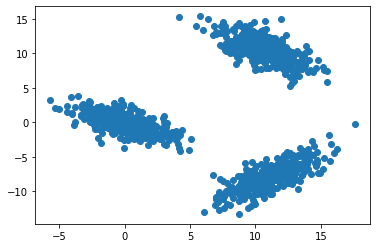

In [6]:
plt.scatter(dataset['X1'],dataset['X2'])

In [7]:
def separate_by_class(dataset):
	separated = dict()
	for i in range(len(dataset)):
		vector = dataset[i]
		class_value = vector[-1]
		if (class_value not in separated):
			separated[class_value] = list()
		separated[class_value].append(vector)
	return separated

In [8]:
Data1 = separate_by_class(LData)

In [9]:
Data1

{1.0: [array([-0.9285 , -0.71995,  1.     ]),
  array([-3.2746,  2.4436,  1.    ]),
  array([0.50871, 0.64457, 1.     ]),
  array([ 0.59212, -1.3693 ,  1.     ]),
  array([ 2.1432, -2.6496,  1.    ]),
  array([-1.4012 ,  0.73143,  1.     ]),
  array([-1.0752 , -0.94375,  1.     ]),
  array([-0.26652,  0.79366,  1.     ]),
  array([-1.5436 , -0.10377,  1.     ]),
  array([-0.93854, -1.5054 ,  1.     ]),
  array([0.30636, 1.3604 , 1.     ]),
  array([-0.91351, -0.29203,  1.     ]),
  array([0.4619 , 0.82578, 1.     ]),
  array([-2.7482 ,  0.86637,  1.     ]),
  array([-1.9228 ,  0.42743,  1.     ]),
  array([ 1.7649, -1.7965,  1.    ]),
  array([-4.4297,  2.3129,  1.    ]),
  array([-1.1589 , -0.60859,  1.     ]),
  array([-2.0733,  1.956 ,  1.    ]),
  array([-0.76247,  2.0085 ,  1.     ]),
  array([-2.4187,  1.9154,  1.    ]),
  array([ 0.080135, -2.4906  ,  1.      ]),
  array([-0.86699, -0.74075,  1.     ]),
  array([-1.6377 , -0.70615,  1.     ]),
  array([-0.50767,  0.99647,  1.   

In [10]:
meu = []
for i in Data1:
  M = []
  for j in range(len(Data1[i][0])-1):
    Data = np.asarray(Data1[i])
    M.append(np.sum(Data[:][:,j])/len(Data[:][:,j]))
  meu.append(M)

In [11]:
meu = np.asarray(meu)

In [12]:
meu

array([[ 0.11049909, -0.14947142],
       [10.665218  , 10.511364  ],
       [11.24764371, -7.81517003]])

In [13]:
Covariance_Matrix = []
for i in Data1:
  Data = np.asarray(Data1[i])
  conv = np.zeros([2,2])
  for k in range(0, 2):
    for j in range(0, 2):
      a = Data[:][:,k]
      b = Data[:][:,j]
      a_mean = np.mean(a)
      b_mean = np.mean(b)
      sum = 0
      for l in range(0, len(a)):
          sum += ((a[l] - a_mean) * (b[l] - b_mean))
      #print(sum/len(a)-1)
      conv[k][j] = sum/(len(a)-1)
  Covariance_Matrix.append(conv)

In [14]:
Covariance_Matrix

[array([[ 4.00120544, -1.97041452],
        [-1.97041452,  2.2065844 ]]), array([[ 3.4193959 , -2.30650294],
        [-2.30650294,  3.42358592]]), array([[3.81993808, 2.86737734],
        [2.86737734, 3.82415238]])]

In [15]:
Covarience_Matrix = []
for i in Data1:
  Data = np.asarray(Data1[i])
  Covarience_Matrix.append(np.cov(Data[:][:,0],Data[:][:,1]))


In [16]:
Covarience_Matrix = np.asarray(Covarience_Matrix)
print(Covarience_Matrix)

[[[ 4.00120544 -1.97041452]
  [-1.97041452  2.2065844 ]]

 [[ 3.4193959  -2.30650294]
  [-2.30650294  3.42358592]]

 [[ 3.81993808  2.86737734]
  [ 2.86737734  3.82415238]]]


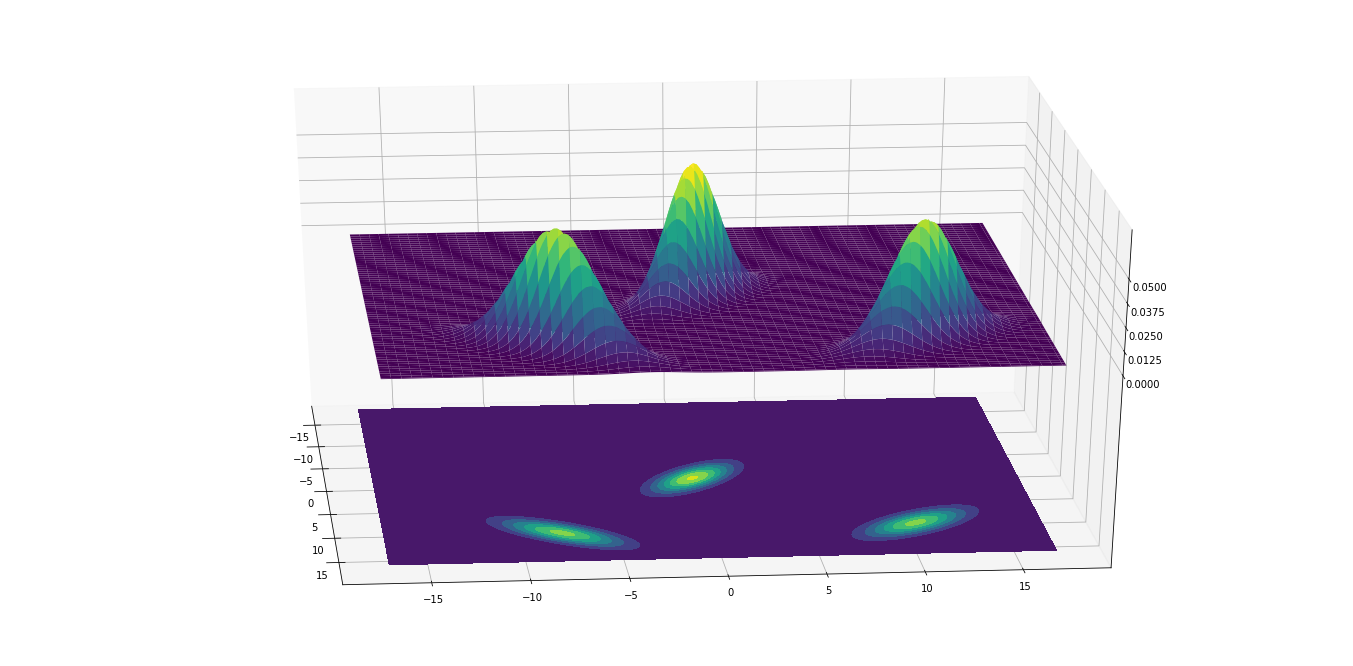

In [17]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Mean vector and covariance matrix
mu = np.asarray(meu[1])
Sigma = np.asarray(Covariance_Matrix[1])

# Our 2-dimensional distribution will be over variables X and Y
     
X = np.linspace(-17,17 , num=200)
Y = np.linspace(-17, 17, num=200)
X, Y = np.meshgrid(X, Y)

# Pack X and Y into a single 3-dimensional array
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X
pos[:, :, 1] = Y

def multivariate_gaussian(pos, mu, Sigma):
    """Return the multivariate Gaussian distribution on array pos.

    pos is an array constructed by packing the meshed arrays of variables
    x_1, x_2, x_3, ..., x_k into its _last_ dimension.

    """

    n = mu.shape[0]
    Sigma_det = np.linalg.det(Sigma)
    Sigma_inv = np.linalg.inv(Sigma)
    N = np.sqrt((2*np.pi)**n * Sigma_det)
    # This einsum call calculates (x-mu)T.Sigma-1.(x-mu) in a vectorized
    # way across all the input variables.
    fac = np.einsum('...k,kl,...l->...', pos-mu, Sigma_inv, pos-mu)

    return np.exp(-fac / 2) / N

# The distribution on the variables X, Y packed into pos.
mu = np.asarray(meu[0])
Sigma = np.asarray(Covariance_Matrix[0])
Z = multivariate_gaussian(pos, mu, Sigma)
mu = np.asarray(meu[1])
Sigma = np.asarray(Covariance_Matrix[1])
Z = Z+multivariate_gaussian(pos, mu, Sigma)
mu = np.asarray(meu[2])
Sigma = np.asarray(Covariance_Matrix[2])
Z = Z+multivariate_gaussian(pos, mu, Sigma)
# Create a surface plot and projected filled contour plot under it.
fig = plt.figure(figsize=(24,12))
ax = fig.gca(projection='3d')
ax.plot_surface(X, Y, Z, rstride=3, cstride=3, linewidth=1, antialiased=True,
                cmap=cm.viridis)
cset = ax.contourf(X, Y, Z, zdir='z', offset=-0.1, cmap=cm.viridis)

# Adjust the limits, ticks and view angle
ax.set_zlim(-0.1,np.max(Z))
ax.set_zticks(np.linspace(0,0.05,5))
ax.view_init(27,-5)

plt.show()

Assumption Every Class has equal Covariance matrix (Covariance matrix of class1)
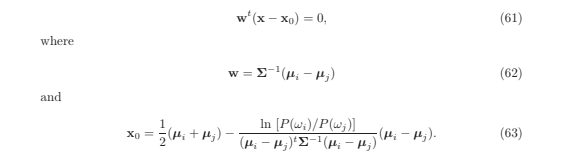

In [18]:
conv = np.zeros([2,2])
for k in range(0, 2):
  for j in range(0, 2):
    a = LData[:][:,k]
    b = LData[:][:,j]
    a_mean = np.mean(a)
    b_mean = np.mean(b)
    sum = 0
    for l in range(0, len(a)):
        sum += ((a[l] - a_mean) * (b[l] - b_mean))
      #print(sum/len(a)-1)
    conv[k][j] = sum/(len(a)-1)
print(conv)

[[29.9621545   1.36326989]
 [ 1.36326989 59.67462493]]


In [19]:
W = np.linalg.inv(conv)@(meu[0]-meu[1])
X = np.linspace(-17,17 , num=200)
Y = np.linspace(-17, 17, num=200)
X, Y = np.meshgrid(X, Y)
print(W)


[-0.34449794 -0.17077932]


In [20]:
X1 = np.linspace(-17,17 , num=200)
Eqn12 = -0.34449794*(X1)/0.17077932+0.34449794*(meu[0][0]+meu[1][0])/(2*0.17077932)+(meu[0][1]+meu[1][1])/2

In [21]:
Eqn12 

array([ 5.03419831e+01,  4.99973339e+01,  4.96526848e+01,  4.93080357e+01,
        4.89633865e+01,  4.86187374e+01,  4.82740883e+01,  4.79294391e+01,
        4.75847900e+01,  4.72401409e+01,  4.68954917e+01,  4.65508426e+01,
        4.62061935e+01,  4.58615443e+01,  4.55168952e+01,  4.51722461e+01,
        4.48275969e+01,  4.44829478e+01,  4.41382987e+01,  4.37936495e+01,
        4.34490004e+01,  4.31043513e+01,  4.27597021e+01,  4.24150530e+01,
        4.20704039e+01,  4.17257547e+01,  4.13811056e+01,  4.10364565e+01,
        4.06918073e+01,  4.03471582e+01,  4.00025091e+01,  3.96578599e+01,
        3.93132108e+01,  3.89685617e+01,  3.86239126e+01,  3.82792634e+01,
        3.79346143e+01,  3.75899652e+01,  3.72453160e+01,  3.69006669e+01,
        3.65560178e+01,  3.62113686e+01,  3.58667195e+01,  3.55220704e+01,
        3.51774212e+01,  3.48327721e+01,  3.44881230e+01,  3.41434738e+01,
        3.37988247e+01,  3.34541756e+01,  3.31095264e+01,  3.27648773e+01,
        3.24202282e+01,  

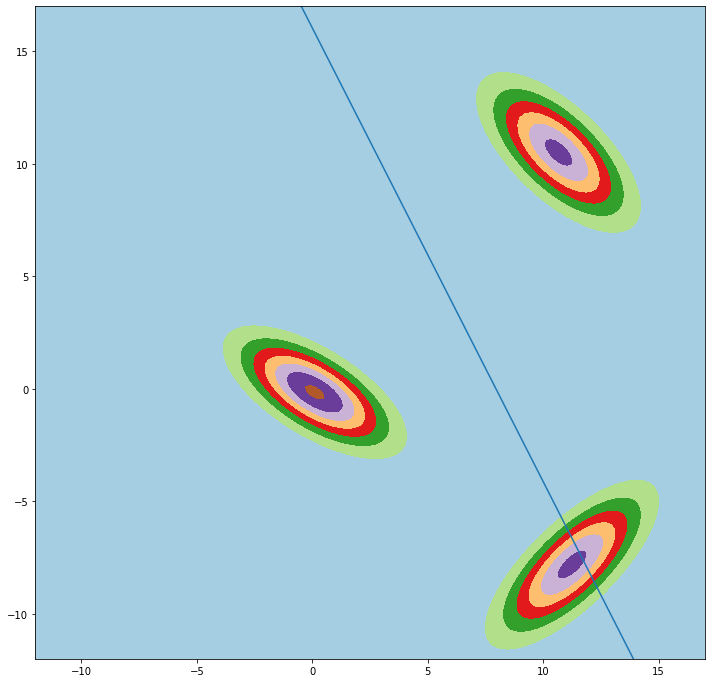

In [22]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn12)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [23]:
W = np.linalg.inv(conv)@(meu[0]-meu[2])
X = np.linspace(-17,17 , num=200)
Y = np.linspace(-17, 17, num=200)
X, Y = np.meshgrid(X, Y)
print(W)


[-0.37794474  0.13709243]


In [24]:

Eqn13 = 0.37794474 *(X1)/0.13709243-0.37794474 *(meu[0][0]+meu[2][0])/(2*0.13709243)+(meu[0][1]+meu[2][1])/2

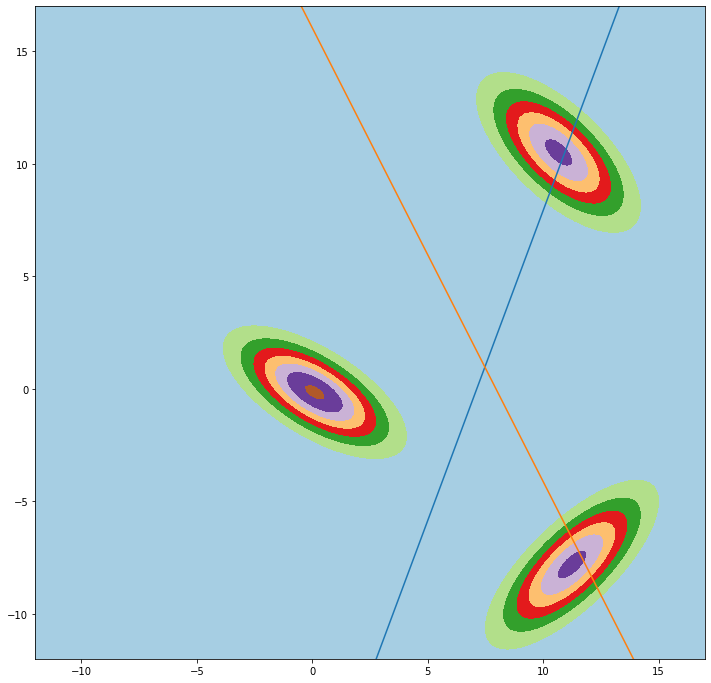

In [25]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn13)
plt.plot(X1,Eqn12)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [26]:
W = np.linalg.inv(conv)@(meu[1]-meu[2])
X = np.linspace(-17,17 , num=200)
Y = np.linspace(-17, 17, num=200)
X, Y = np.meshgrid(X, Y)
print(W)

[-0.03344679  0.30787175]


In [27]:
Eqn23 = 0.03344679*(X1)/0.30787175 - 0.03344679*(meu[1][0]+meu[2][0])/(2*0.30787175)+(meu[1][1]+meu[2][1])/2

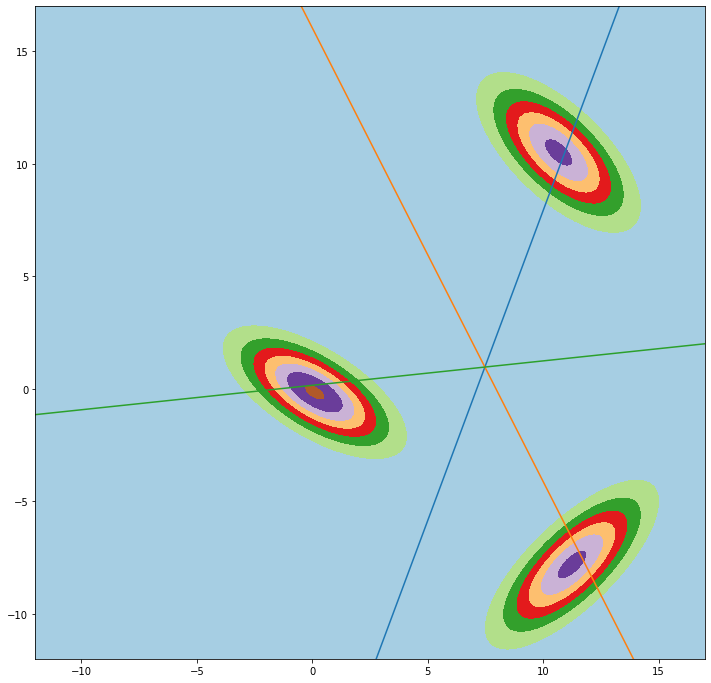

In [28]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn13)
plt.ylim([-10, 5])
plt.plot(X1,Eqn12)
plt.plot(X1,Eqn23)
#plt.scatter(dataset['X1'],dataset['X2'])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [29]:
idx = np.argwhere(np.diff(np.sign(Eqn12 - Eqn13))).flatten()
idx

array([143])

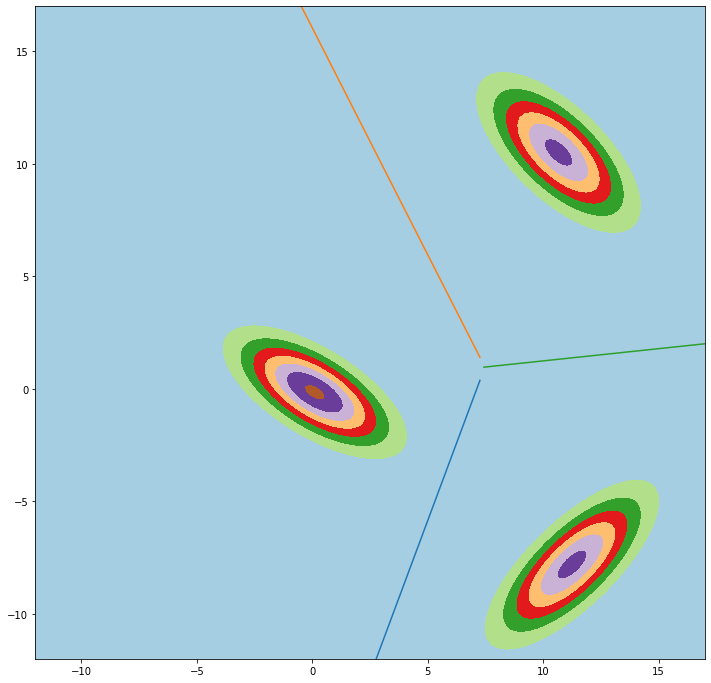

In [30]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1[:143],Eqn13[:143])
plt.ylim([-10, 5])
plt.plot(X1[:143],Eqn12[:143])
plt.plot(X1[143:],Eqn23[143:])
#plt.scatter(dataset['X1'],dataset['X2'])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

Case 2

In [31]:
Covariance_Matrix

[array([[ 4.00120544, -1.97041452],
        [-1.97041452,  2.2065844 ]]), array([[ 3.4193959 , -2.30650294],
        [-2.30650294,  3.42358592]]), array([[3.81993808, 2.86737734],
        [2.86737734, 3.82415238]])]

In [32]:
w1 = (np.linalg.inv(Covariance_Matrix[0])@meu[0]-np.linalg.inv(Covariance_Matrix[1])@meu[1])
w01 = -0.5*(meu[0].T@np.linalg.inv(Covariance_Matrix[0])@meu[0]-meu[1].T@np.linalg.inv(Covariance_Matrix[1])@meu[1])-0.5*np.log(np.abs(np.linalg.det(Covariance_Matrix[0])/np.linalg.det(Covariance_Matrix[1])))
W1 = -0.5*(np.linalg.inv(Covariance_Matrix[0])-np.linalg.inv(Covariance_Matrix[1]))
print(w1,w01,W1)

[-9.5235114  -9.55634672] 100.67410407531098 [[ 0.04498052 -0.01860155]
 [-0.01860155 -0.13675194]]


In [33]:
Eqn212 = 0.04498052*X**2 - 0.13675194*Y**2 - 2*0.01860155*X*Y - 9.5235114*X - 9.55634672*Y + 100.418568796071

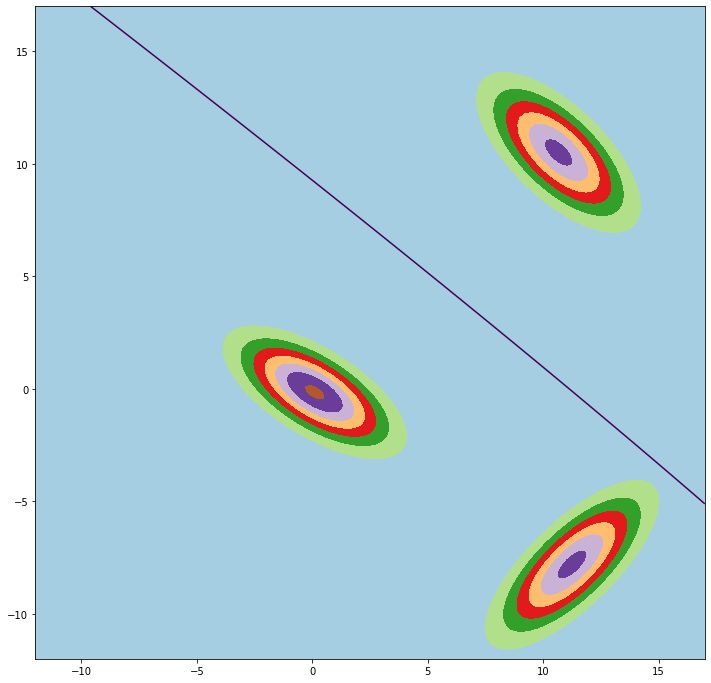

In [34]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X, Y, Eqn212,[0])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [35]:
w1 = (np.linalg.inv(Covariance_Matrix[0])@meu[0]-np.linalg.inv(Covariance_Matrix[2])@meu[2])
w01 = -0.5*(meu[0].T@np.linalg.inv(Covariance_Matrix[0])@meu[0]-meu[2].T@np.linalg.inv(Covariance_Matrix[2])@meu[2])-0.5*np.log(np.abs(np.linalg.det(Covariance_Matrix[0])/np.linalg.det(Covariance_Matrix[2])))
W1 = -0.5*(np.linalg.inv(Covariance_Matrix[0])-np.linalg.inv(Covariance_Matrix[2]))
print(w1,w01,W1)

[-10.25452964   9.64798043] 95.73532208954015 [[ 0.07636215 -0.42367294]
 [-0.42367294 -0.10537224]]


In [36]:
Eqn213 = 0.07636215*X**2 - 0.10537224*Y**2 - 2*0.42367294*X*Y - 10.25452964*X + 9.64798043*Y + 95.7353220895401

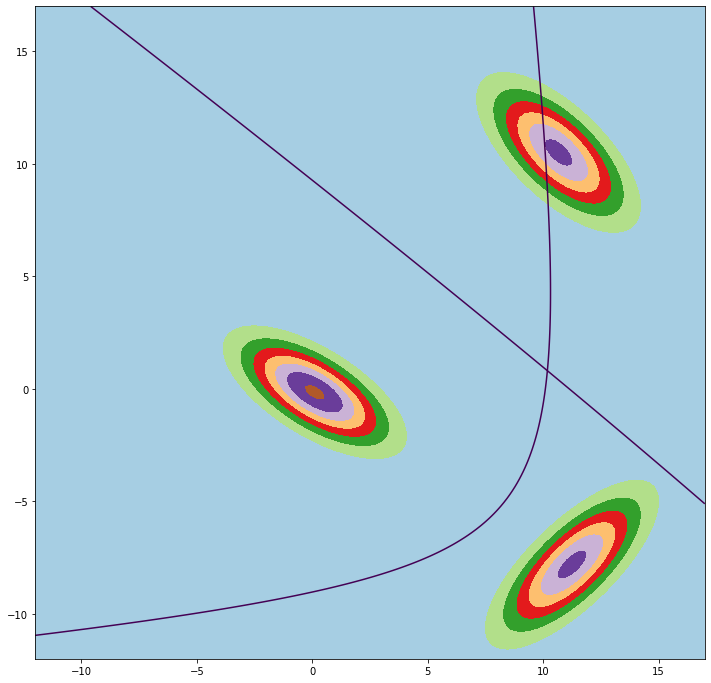

In [37]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X, Y, Eqn212,[0])
plt.contour(X, Y, Eqn213,[0])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [38]:
w1 = (np.linalg.inv(Covariance_Matrix[1])@meu[1]-np.linalg.inv(Covariance_Matrix[2])@meu[2])
w01 = -0.5*(meu[1].T@np.linalg.inv(Covariance_Matrix[1])@meu[1]-meu[2].T@np.linalg.inv(Covariance_Matrix[2])@meu[2])-0.5*np.log(np.abs(np.linalg.det(Covariance_Matrix[1])/np.linalg.det(Covariance_Matrix[2])))
W1 = -0.5*(np.linalg.inv(Covariance_Matrix[1])-np.linalg.inv(Covariance_Matrix[2]))
print(w1,w01,W1)

[-0.73101824 19.20432715] -4.938781985770837 [[ 0.03138163 -0.40507139]
 [-0.40507139  0.0313797 ]]


In [39]:
Eqn223 = 0.03138163*X**2 + 0.0313797*Y**2 - 2*0.40507139*X*Y - 0.73101824*X + 19.20432715*Y - 4.938781985770907

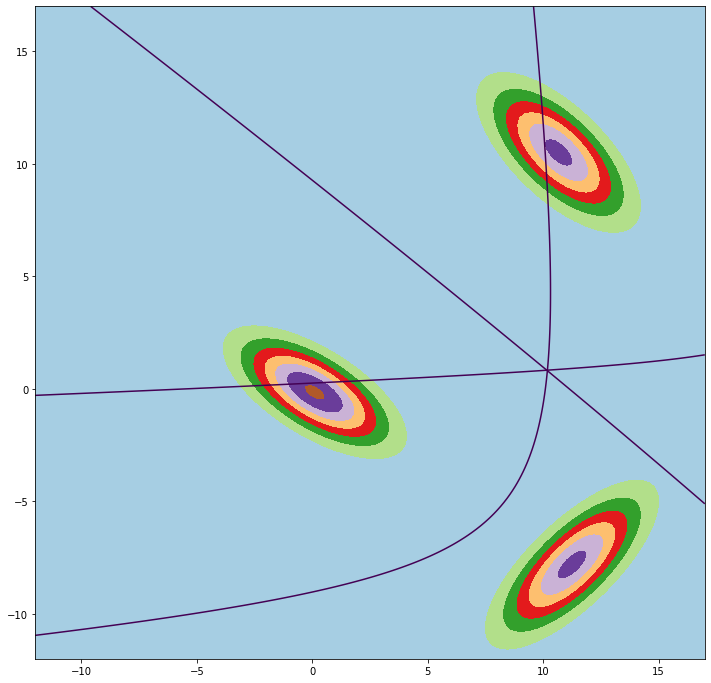

In [40]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X, Y, Eqn212,[0])
plt.contour(X, Y, Eqn213,[0])
plt.contour(X, Y, Eqn223,[0])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [41]:
idx = np.argwhere(np.diff(np.sign(Eqn213[:,:50] - Eqn223[:,:50]))).flatten()
idx

array([195,  48, 196,  47, 197,  46, 198,  44, 199,  43])

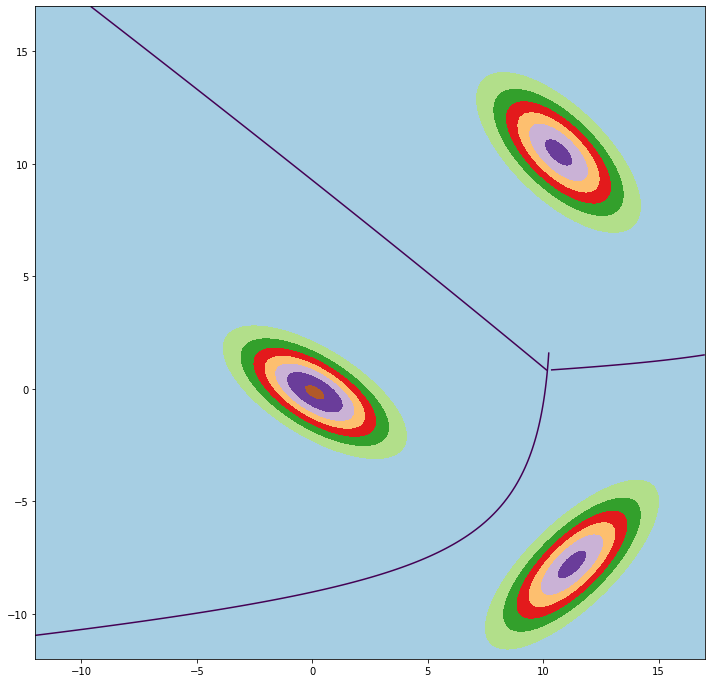

In [42]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X[:,:160], Y[:,:160], Eqn212[:,:160],[0])
plt.contour(X[:110], Y[:110], Eqn213[:110],[0])
plt.contour(X[:,160:], Y[:,160:], Eqn223[:,160:],[0])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

**Case3**
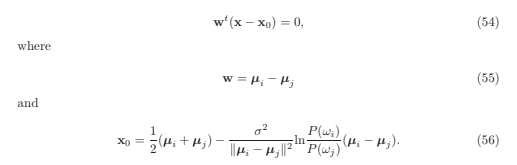

In [43]:
W31 = meu[0] - meu[1]
W31

array([-10.55471891, -10.66083542])

In [44]:
Eqn312 = -10.55471891*(X1)/10.66083542+10.55471891*(meu[0][0]+meu[1][0])/(2*10.66083542)+(meu[0][1]+meu[1][1])/2

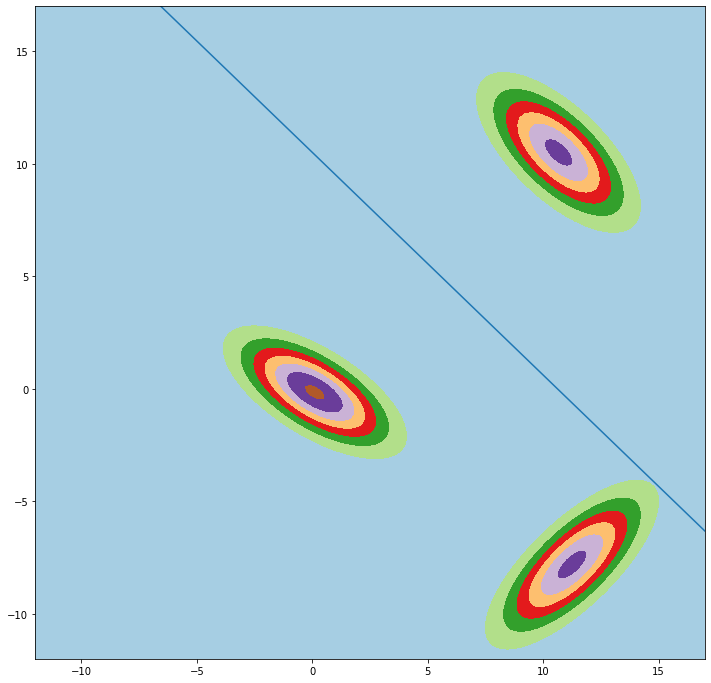

In [45]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn312)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [46]:
W32 = meu[0] - meu[2]
W32

array([-11.13714462,   7.66569861])

In [47]:
Eqn313 = 11.13714462*(X1)/7.66569861 - 11.13714462*(meu[0][0]+meu[2][0])/(2*7.66569861)+(meu[0][1]+meu[2][1])/2

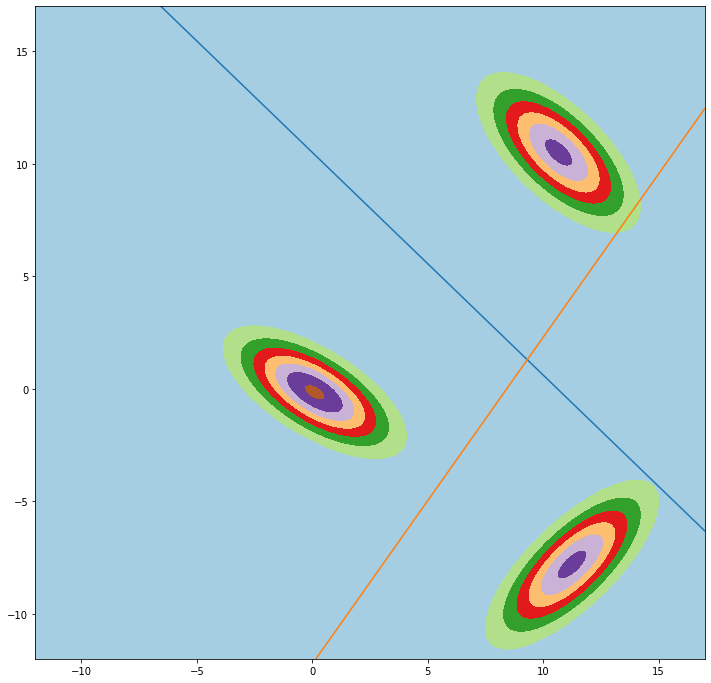

In [48]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn312)
plt.plot(X1,Eqn313)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [49]:
W33 = meu[1] - meu[2]
W33

array([-0.58242571, 18.32653403])

In [50]:
Eqn323 = -0.58242571*(X1)/18.32653403 + 0.58242571*(meu[1][0]+meu[2][0])/(2*18.32653403)+(meu[1][1]+meu[2][1])/2

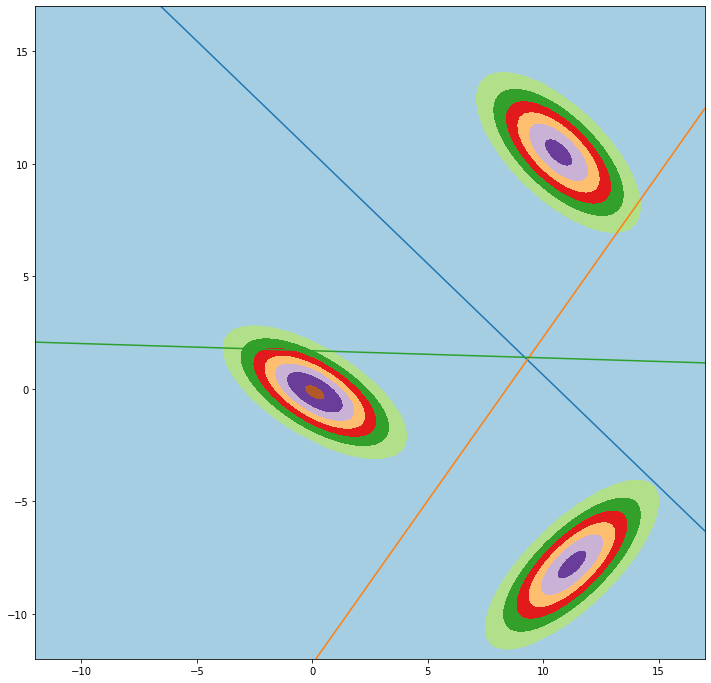

In [51]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn312)
plt.plot(X1,Eqn313)
plt.plot(X1,Eqn323)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [52]:
idx = np.argwhere(np.diff(np.sign(Eqn312 - Eqn313))).flatten()
idx

array([154])

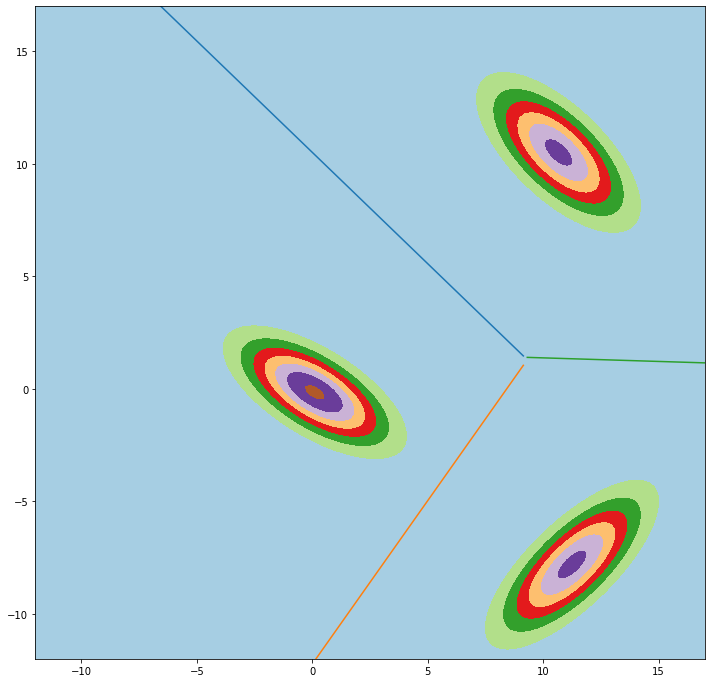

In [53]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1[:154],Eqn312[:154])
plt.plot(X1[:154],Eqn313[:154])
plt.plot(X1[154:],Eqn323[154:])
#plt.scatter(dataset['X1'],dataset['X2'])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

Case 4 Diagonal Covariance Matrix of Class1
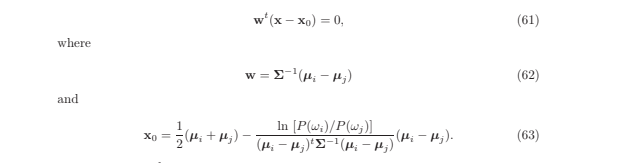

In [54]:
cov = conv
cov[0][1]=0
cov[1][0]=0
W4 = np.linalg.inv(cov)@(meu[0]-meu[1])
print(conv)
print(W4)


[[29.9621545   0.        ]
 [ 0.         59.67462493]]
[-0.35226836 -0.17864939]


In [55]:
Eqn412 = -0.35226836*(X1)/0.17864939+0.35226836*(meu[0][0]+meu[1][0])/(2*0.17864939)+(meu[0][1]+meu[1][1])/2

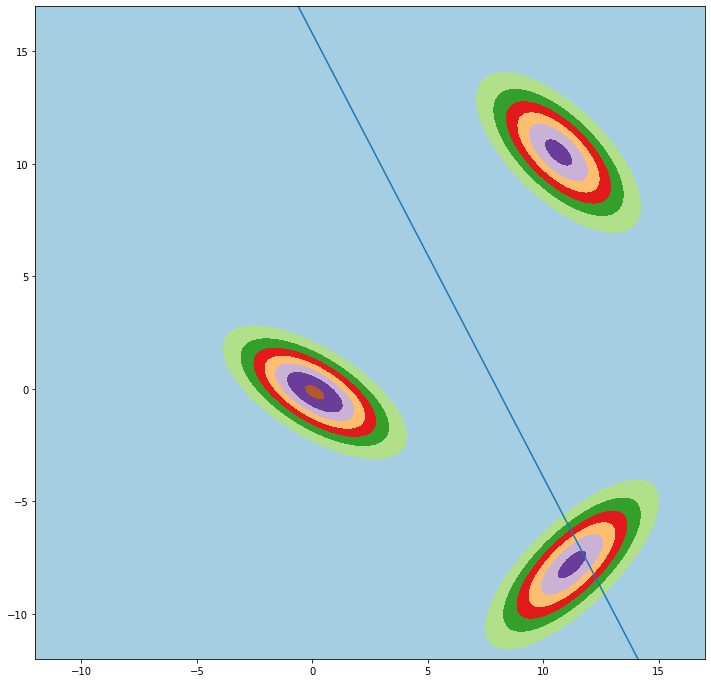

In [56]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn412)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [57]:
W4 = np.linalg.inv(cov)@(meu[0]-meu[2])
print(W4)


[-0.37170707  0.12845826]


In [58]:
Eqn413 = 0.37170707*(X1)/0.12845826 - 0.37170707*(meu[0][0]+meu[2][0])/(2*0.12845826)+(meu[0][1]+meu[2][1])/2

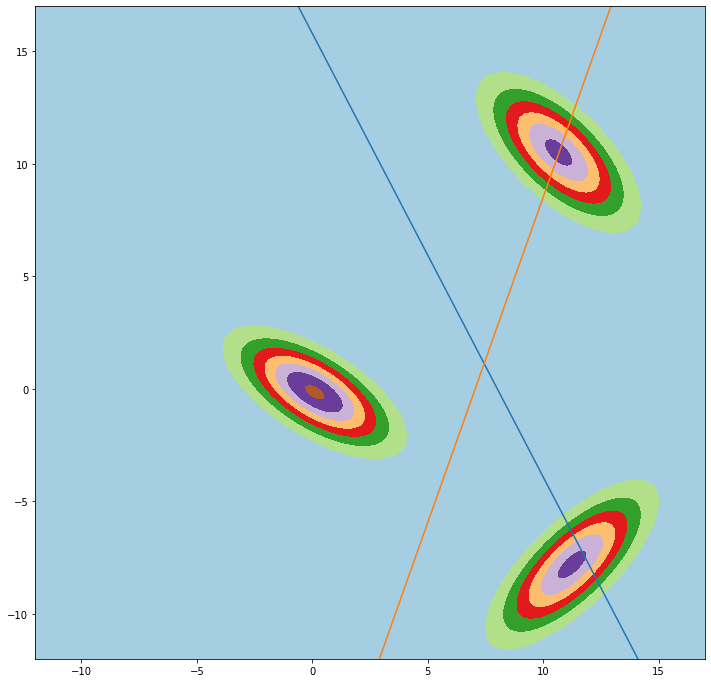

In [59]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn412)
plt.plot(X1,Eqn413)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [60]:
W4 = np.linalg.inv(cov)@(meu[1]-meu[2])
print(W4)

[-0.01943871  0.30710765]


In [61]:
Eqn423 = 0.01943871*(X1)/0.30710765- 0.01943871*(meu[1][0]+meu[2][0])/(2*0.30710765)+(meu[1][1]+meu[2][1])/2

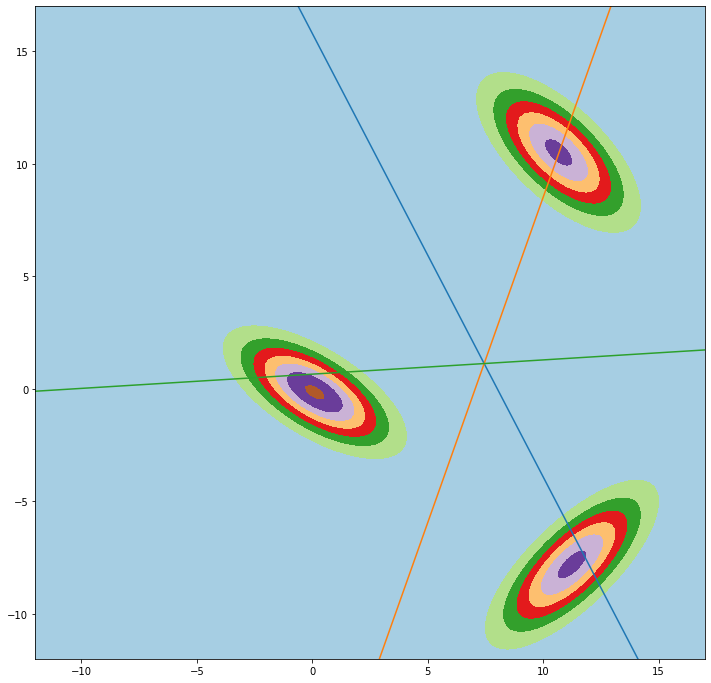

In [62]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn412)
plt.plot(X1,Eqn413)
plt.plot(X1,Eqn423)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [63]:
idx = np.argwhere(np.diff(np.sign(Eqn412 - Eqn413))).flatten()
idx

array([143])

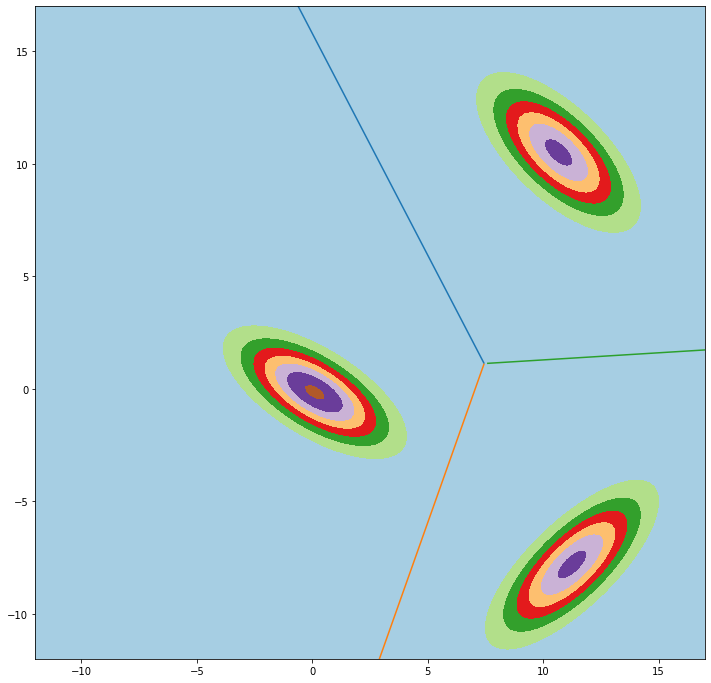

In [64]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1[:144],Eqn412[:144])
plt.plot(X1[:144],Eqn413[:144])
plt.plot(X1[144:],Eqn423[144:])
#plt.scatter(dataset['X1'],dataset['X2'])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

Case 5
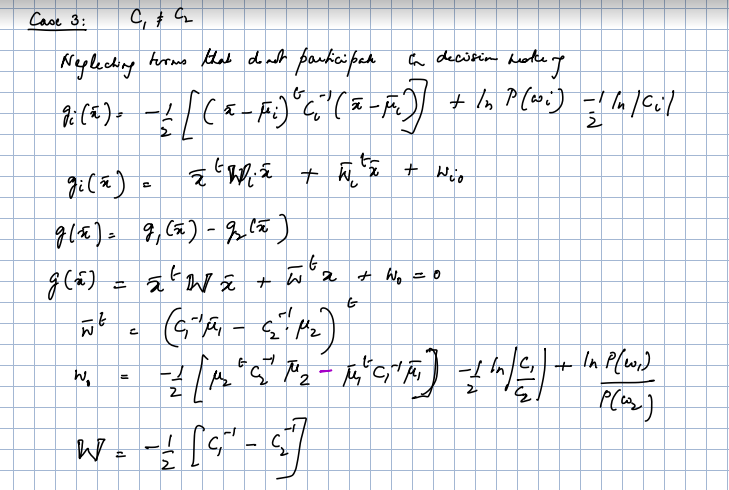

In [65]:
cov = Covariance_Matrix
cov[0][0][1]=0 
cov[0][1][0]=0
cov[1][0][1]=0 
cov[1][1][0]=0
cov[2][0][1]=0 
cov[2][1][0]=0
cov

[array([[4.00120544, 0.        ],
        [0.        , 2.2065844 ]]), array([[3.4193959 , 0.        ],
        [0.        , 3.42358592]]), array([[3.81993808, 0.        ],
        [0.        , 3.82415238]])]

In [66]:
w = (np.linalg.inv(cov[0])@meu[0]-np.linalg.inv(cov[1])@meu[1])
w0 = -0.5*(meu[0].T@np.linalg.inv(cov[0])@meu[0]-meu[1].T@np.linalg.inv(cov[1])@meu[1])-0.5*np.log(np.abs(np.linalg.det(cov[0])/np.linalg.det(cov[1])))
W = -0.5*(np.linalg.inv(cov[0])-np.linalg.inv(cov[1]))
print(w,w0,W)

[-3.09141928 -3.13801783] 32.90347532804599 [[ 0.02126232 -0.        ]
 [-0.         -0.08054885]]


In [67]:
Eqn512 = 0.02126232*X**2 - 0.08054885*Y**2 - 3.09141928*X - 3.13801783*Y + 32.903475328046

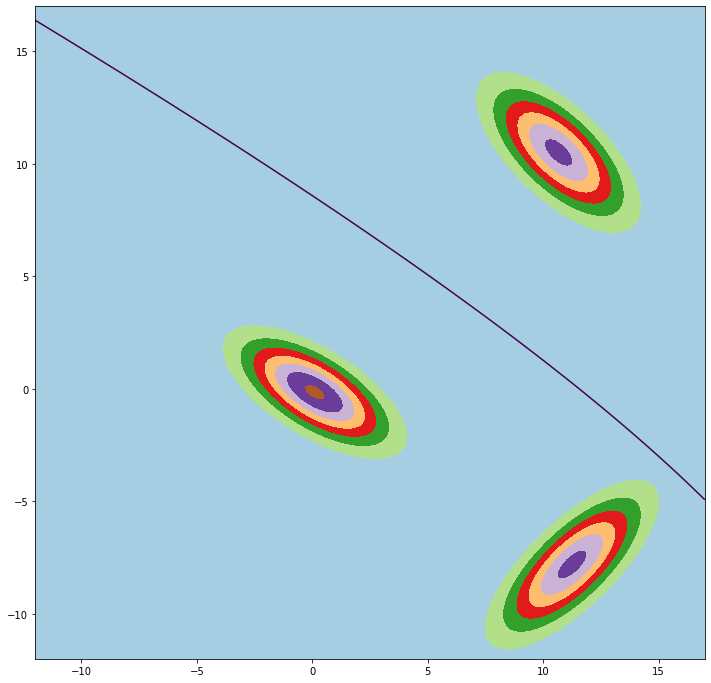

In [68]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X, Y, Eqn512, [0])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [69]:
w = (np.linalg.inv(cov[0])@meu[0]-np.linalg.inv(cov[2])@meu[2])
w0 = -0.5*(meu[0].T@np.linalg.inv(cov[0])@meu[0]-meu[2].T@np.linalg.inv(cov[2])@meu[2])-0.5*np.log(np.abs(np.linalg.det(cov[0])/np.linalg.det(cov[2])))
W = -0.5*(np.linalg.inv(cov[0])-np.linalg.inv(cov[2]))
print(w,w0,W)

[-2.91684063  1.97589576] 24.78995438613117 [[ 0.00592983 -0.        ]
 [-0.         -0.09584662]]


In [70]:
Eqn513 = 0.00592983*X**2 - 0.09584662*Y**2 - 2.91684063*X + 1.97589576*Y + 24.789954386131182

In [71]:
Eqn513.shape

(200, 200)

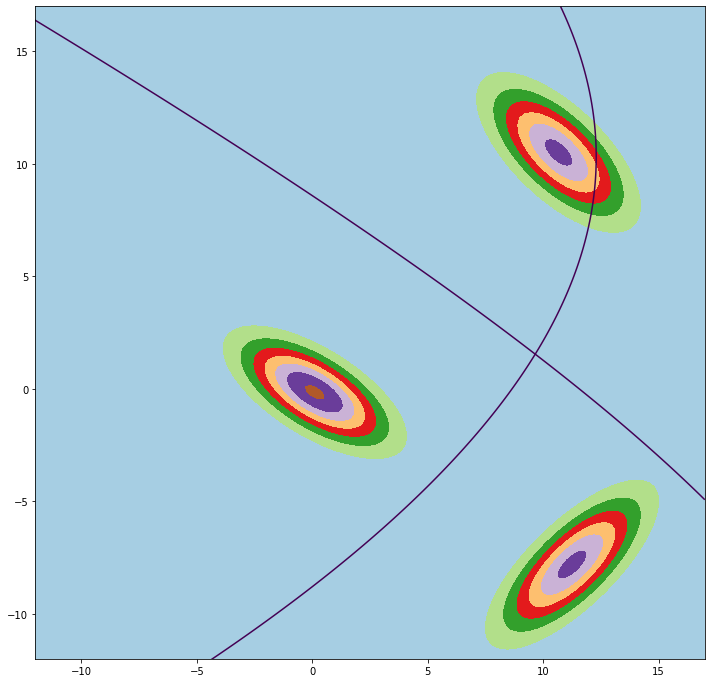

In [72]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X, Y, Eqn512, [0])
plt.contour(X, Y, Eqn513, [0])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [73]:
w = (np.linalg.inv(cov[1])@meu[1]-np.linalg.inv(cov[2])@meu[2])
w0 = -0.5*(meu[1].T@np.linalg.inv(cov[1])@meu[1]-meu[2].T@np.linalg.inv(cov[2])@meu[2])-0.5*np.log(np.abs(np.linalg.det(cov[1])/np.linalg.det(cov[2])))
W = -0.5*(np.linalg.inv(cov[1])-np.linalg.inv(cov[2]))
print(w,w0,W)

[0.17457865 5.11391359] -8.113520941914818 [[-0.01533248 -0.        ]
 [-0.         -0.01529777]]


In [74]:
Eqn523 = -0.01533248*X**2 - 0.01529777*Y**2 + 0.17457865*X + 5.11391359*Y - 8.113520941914818

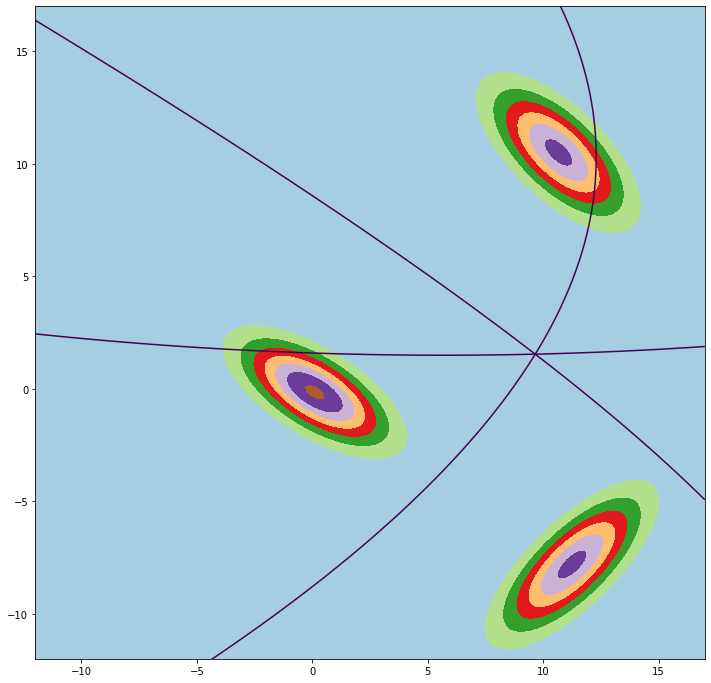

In [75]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
custom_xlim = (10,15)
custom_ylim = (15,-15)
plt.contour(X, Y, Eqn512, [0])
plt.contour(X, Y, Eqn513, [0])
plt.contour(X, Y, Eqn523, [0])

#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [76]:
idx = np.argwhere(np.diff(np.sign(Eqn512 - Eqn513))).flatten()
idx

array([109,  94, 109, 170, 110,  74, 110, 190, 111,  60, 112,  47, 113,
        37, 114,  27, 115,  18, 116,  10, 117,   3])

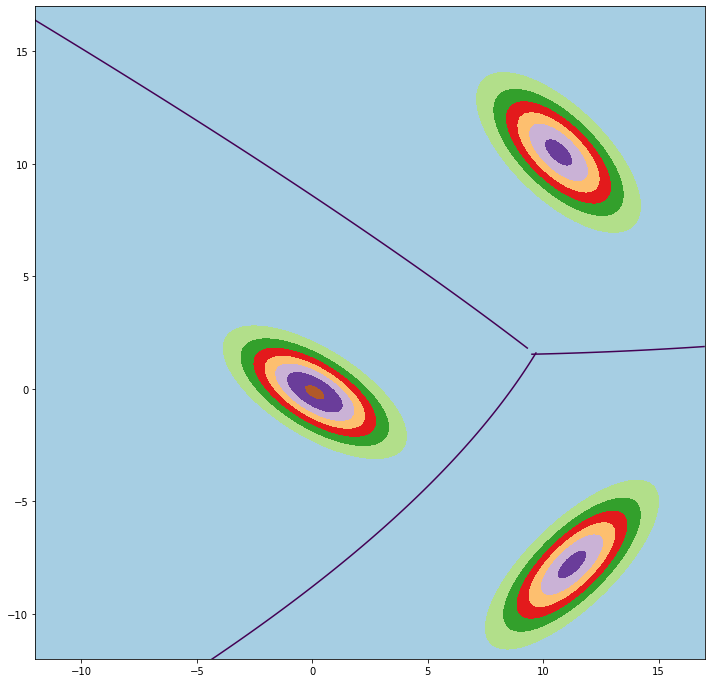

In [77]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X[110:], Y[110:], Eqn512[110:], [0])
plt.contour(X[:110], Y[:110], Eqn513[:110], [0])
plt.contour(X[:,155:], Y[:,155:], Eqn523[:,155:], [0])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

Non-Linear Data

In [78]:
from numpy import loadtxt
NLData = loadtxt("trian.txt", delimiter=",", unpack=False)

In [79]:
Data2 = separate_by_class(NLData)

In [115]:
Data21=np.asarray(Data2[1.0])
Data22=np.asarray(Data2[2.0])
Data23=np.asarray(Data2[3.0])

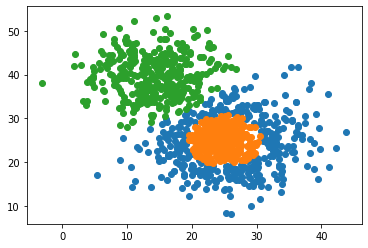

In [118]:
plt.scatter(Data21[:,0],Data21[:,1])
plt.scatter(Data22[:,0],Data22[:,1])
plt.scatter(Data23[:,0],Data23[:,1])

In [80]:
meu1 = []
for i in Data2:
  M = []
  for j in range(len(Data2[i][0])-1):
    Data = np.asarray(Data2[i])
    M.append(np.sum(Data[:][:,j])/len(Data[:][:,j]))
  meu1.append(M)

In [81]:
Covariance_Matrix1 = []
for i in Data2:
  Data = np.asarray(Data2[i])
  conv = np.zeros([2,2])
  for k in range(0, 2):
    for j in range(0, 2):
      a = Data[:][:,k]
      b = Data[:][:,j]
      a_mean = np.mean(a)
      b_mean = np.mean(b)
      sum = 0
      for l in range(0, len(a)):
          sum += ((a[l] - a_mean) * (b[l] - b_mean))
      #print(sum/len(a)-1)
      conv[k][j] = sum/(len(a)-1)
  Covariance_Matrix1.append(conv)

In [82]:
meu1 = np.asarray(meu1)

In [83]:
Covariance_Matrix1 = np.asarray(Covariance_Matrix1)

Case1

In [86]:
conv1 = np.zeros([2,2])
for k in range(0, 2):
  for j in range(0, 2):
    a = NLData[:][:,k]
    b = NLData[:][:,j]
    a_mean = np.mean(a)
    b_mean = np.mean(b)
    sum = 0
    for l in range(0, len(a)):
        sum += ((a[l] - a_mean) * (b[l] - b_mean))
      #print(sum/len(a)-1)
    conv1[k][j] = sum/(len(a)-1)
print(conv1)


[[ 55.40949861 -35.65689215]
 [-35.65689215  77.3833439 ]]


In [87]:
W = np.linalg.inv(conv1)@(meu1[0]-meu1[1])
X = np.linspace(0,50 , num=200)
Y = np.linspace(0, 50, num=200)
X, Y = np.meshgrid(X, Y)
print(W)


[ 0.02135351 -0.00488503]


In [88]:
X1 = np.linspace(0,50 , num=200)
Eqn212 = -0.02135351*(X1)/0.00488503 + 0.02135351*(meu1[0][0]+meu1[1][0])/(2*0.00488503)+(meu1[0][1]+meu1[1][1])/2

(10.0, 50.0, 10.0, 50.0)

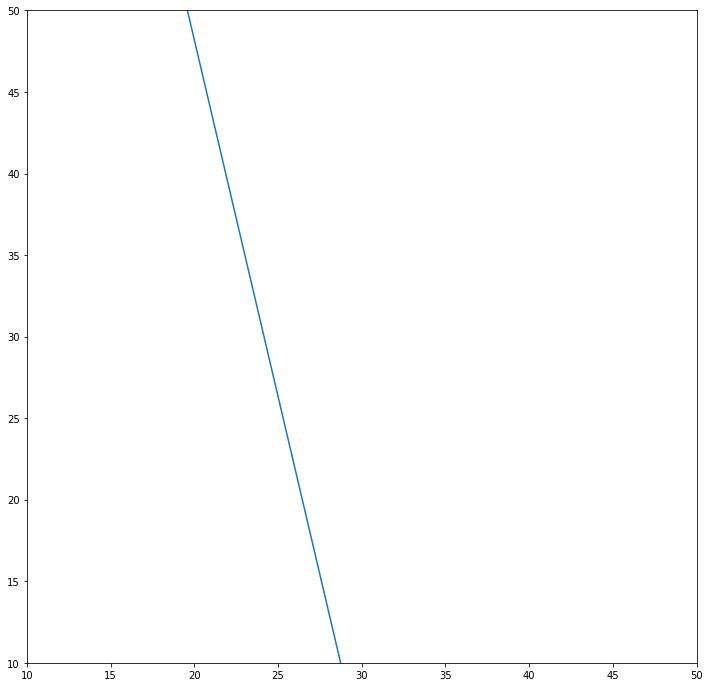

In [89]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.plot(X1,Eqn212)
#plt.contourf(X,Y,Eqn12)
plt.axis([10, 50, 10, 50])

In [90]:
W = np.linalg.inv(conv1)@(meu1[0]-meu1[2])

print(W)

[ 0.11825785 -0.15147413]


In [91]:
Eqn213 = -0.11825785*(X1)/0.15147413 + 0.11825785*(meu1[0][0]+meu1[2][0])/(2*0.15147413)+(meu1[0][1]+meu1[2][1])/2

(0.0, 50.0, 0.0, 50.0)

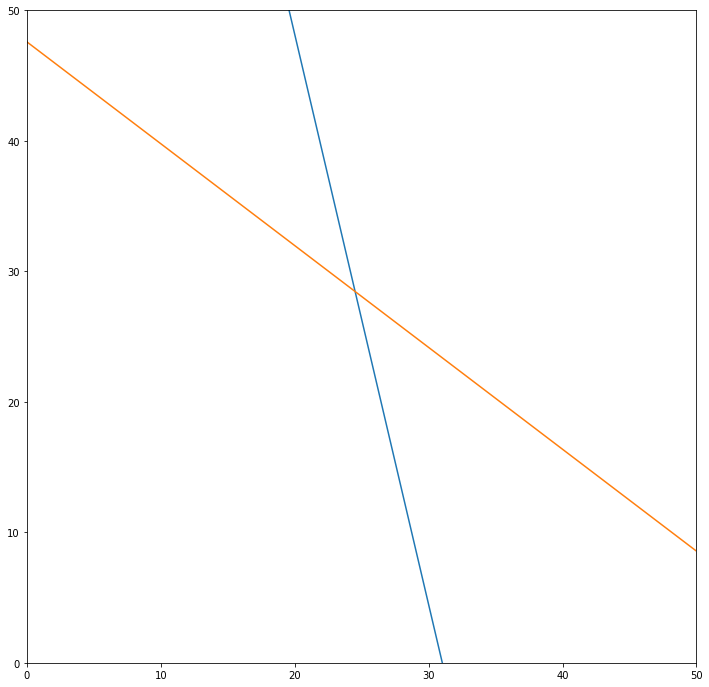

In [92]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.plot(X1,Eqn212)
plt.plot(X1,Eqn213)
#plt.contourf(X,Y,Eqn12)
plt.axis([0, 50, 0, 50])

In [93]:
W = np.linalg.inv(conv1)@(meu1[1]-meu1[2])

print(W)

[ 0.09690435 -0.1465891 ]


In [94]:
Eqn223 = -0.09690435*(X1)/0.1465891 + 0.09690435*(meu1[1][0]+meu1[2][0])/(2*0.1465891)+(meu1[1][1]+meu1[2][1])/2

(0.0, 50.0, 0.0, 50.0)

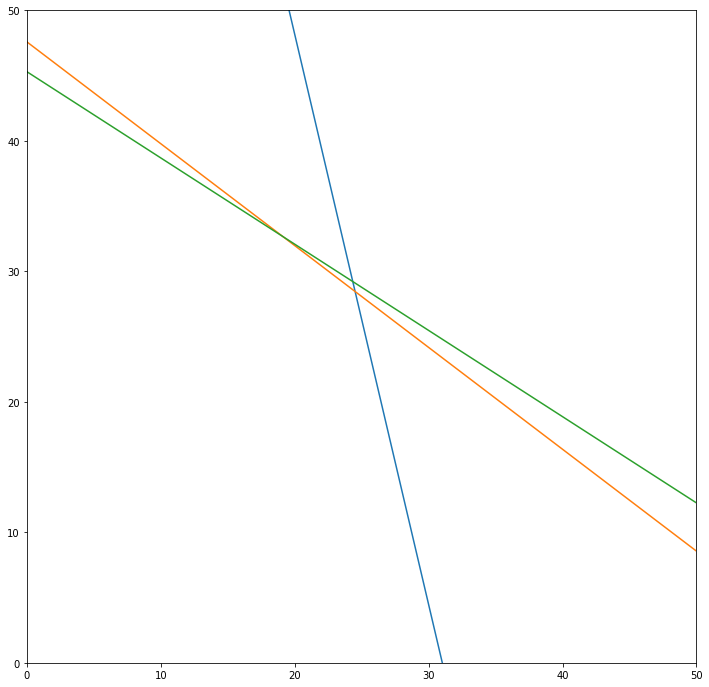

In [95]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.plot(X1,Eqn212)
plt.plot(X1,Eqn213)
plt.plot(X1,Eqn223)
#plt.scatter(dataset1['X1'],dataset1['X2'])
#plt.contourf(X,Y,Eqn12)
plt.axis([0, 50, 0, 50])

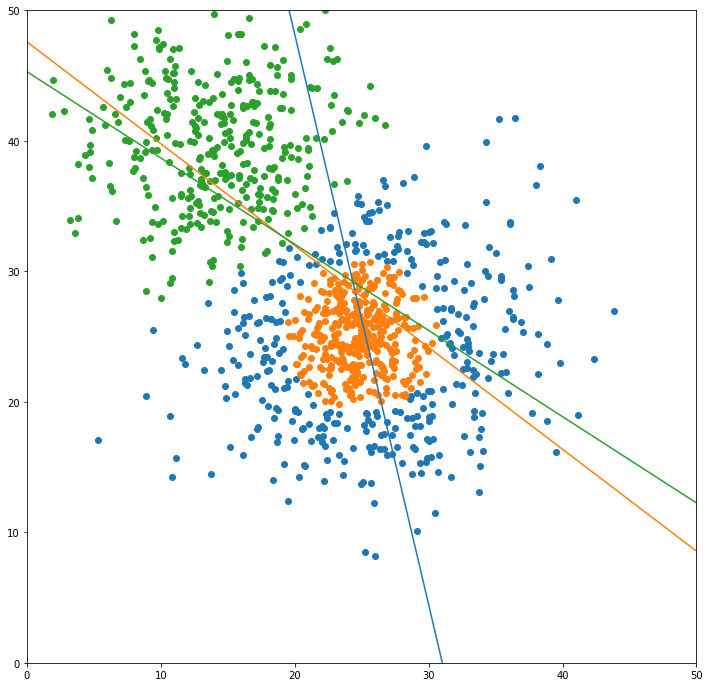

In [174]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.plot(X1,Eqn212)
plt.plot(X1,Eqn213)
plt.plot(X1,Eqn223)
#plt.scatter(dataset1['X1'],dataset1['X2'])
#plt.contourf(X,Y,Eqn12)
plt.axis([0, 50, 0, 50])
plt.scatter(Data21[:,0],Data21[:,1])
plt.scatter(Data22[:,0],Data22[:,1])
plt.scatter(Data23[:,0],Data23[:,1])
plt.show()

case 2

In [97]:
Covariance_Matrix1

array([[[51.55986106,  8.24758231],
        [ 8.24758231, 44.28784134]],

       [[ 5.25536251,  0.08088763],
        [ 0.08088763,  6.8015004 ]],

       [[23.81339307,  1.12367789],
        [ 1.12367789, 22.93995337]]])

In [134]:
Covarience_Matrix1 = []
for i in Data2:
  Data = np.asarray(Data2[i])
  Covarience_Matrix1.append(np.cov(Data[:][:,0],Data[:][:,1]))


In [135]:
Covarience_Matrix1

[array([[51.55986106,  8.24758231],
        [ 8.24758231, 44.28784134]]), array([[5.25536251, 0.08088763],
        [0.08088763, 6.8015004 ]]), array([[23.81339307,  1.12367789],
        [ 1.12367789, 22.93995337]])]

In [98]:
w1 = (np.linalg.inv(Covariance_Matrix1[0])@meu1[0]-np.linalg.inv(Covariance_Matrix1[1])@meu1[1])
w01 = -0.5*(meu1[0].T@np.linalg.inv(Covariance_Matrix1[0])@meu1[0]-meu1[1].T@np.linalg.inv(Covariance_Matrix1[1])@meu1[1])-0.5*np.log(np.abs(np.linalg.det(Covariance_Matrix1[0])/np.linalg.det(Covariance_Matrix1[1])))
W1 = -0.5*(np.linalg.inv(Covariance_Matrix1[0])-np.linalg.inv(Covariance_Matrix1[1]))
print(w1,w01,W1)

[-4.21975092 -3.16916125] 89.81512136520746 [[0.08516312 0.0007297 ]
 [0.0007297  0.06189023]]


In [136]:
Eqn2212 = 0.08516312*X**2 +  0.06189023*Y**2 + 2*0.0007297*X*Y - 4.21975092*X - 3.16916125*Y + 89.81512136520746

In [137]:
Eqn2212.shape

(200, 200)

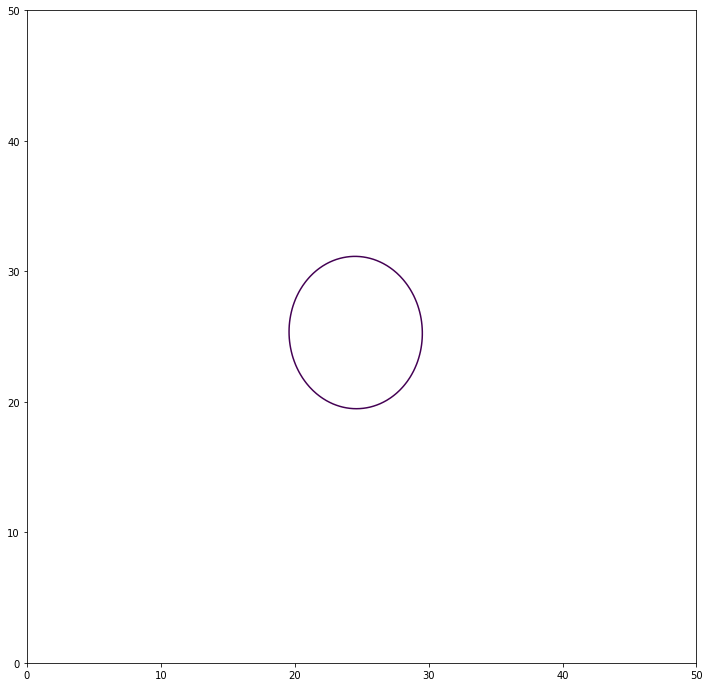

In [185]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Eqn2213,[0])
plt.contour(X,Y,Eqn2212,[0])
#plt.contourf(X,Y,Eqn12)
#plt.axis([0, 50, 0, 50])


In [139]:
w1 = (np.linalg.inv(Covariance_Matrix1[0])@meu1[0]-np.linalg.inv(Covariance_Matrix1[2])@meu1[2])
w01 = -0.5*(meu1[0].T@np.linalg.inv(Covariance_Matrix1[0])@meu1[0]-meu1[2].T@np.linalg.inv(Covariance_Matrix1[2])@meu1[2])-0.5*np.log(np.abs(np.linalg.det(Covariance_Matrix1[0])/np.linalg.det(Covariance_Matrix1[2])))
W1 = -0.5*(np.linalg.inv(Covariance_Matrix1[0])-np.linalg.inv(Covariance_Matrix1[2]))
print(w1,w01,W1)

[-0.08057106 -1.25278042] 25.908569769615013 [[0.01105002 0.00083051]
 [0.00083051 0.01021011]]


In [140]:
Eqn2213 = 0.01105002*X**2 +  0.01021011*Y**2 + 2*0.00083051*X*Y - 0.08057106*X - 1.25278042*Y + 25.908569769615013

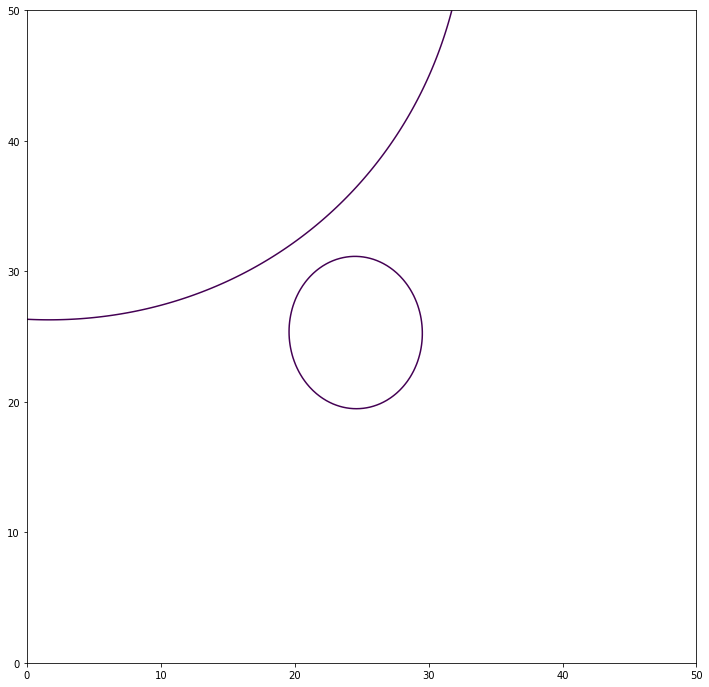

In [184]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Eqn2213,[0])
plt.contour(X,Y,Eqn2212,[0])
plt.contour(X,Y,Eqn2213,[0])
#plt.contourf(X,Y,Eqn12)
#plt.axis([0, 50, 0, 50])


In [144]:
w1 = (np.linalg.inv(Covariance_Matrix1[1])@meu1[1]-np.linalg.inv(Covariance_Matrix1[2])@meu1[2])
w01 = -0.5*(meu1[1].T@np.linalg.inv(Covariance_Matrix1[1])@meu1[1]-meu1[2].T@np.linalg.inv(Covariance_Matrix1[2])@meu1[2])-0.5*np.log(np.abs(np.linalg.det(Covariance_Matrix1[1])/np.linalg.det(Covariance_Matrix1[2])))
W1 = -0.5*(np.linalg.inv(Covariance_Matrix1[1])-np.linalg.inv(Covariance_Matrix1[2]))
print(w1,w01,W1)

[4.13917986 1.91638083] -63.90655159559246 [[-0.0741131   0.00010081]
 [ 0.00010081 -0.05168012]]


In [178]:
Eqn2223 = -0.0741131*X**2 - 0.05168012*Y**2 + 2* 0.00010081*X*Y + 4.13917986*X + 1.91638083*Y - 63.90655159559246

(0.0, 50.0, 0.0, 50.0)

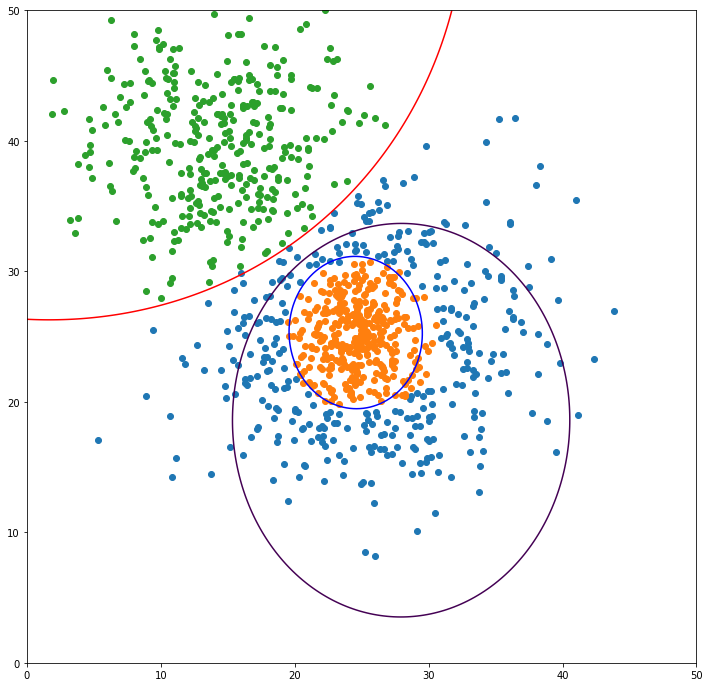

In [187]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Eqn2213,[0])
plt.contour(X,Y,Eqn2212,[0],colors=["b"])
plt.contour(X,Y,Eqn2213,[0],colors=["r"])
plt.contour(X,Y,Eqn2223,[0])
plt.scatter(Data21[:,0],Data21[:,1])
plt.scatter(Data22[:,0],Data22[:,1])
plt.scatter(Data23[:,0],Data23[:,1])
#plt.contourf(X,Y,Eqn12)
plt.axis([0, 50, 0, 50])

Case3


In [152]:
W31 = meu1[0] - meu1[1]
W31

array([ 1.357372  , -1.13941943])

In [158]:
Eqn2312 = 1.357372*(X1)/1.13941943 - 1.357372*(meu1[0][0]+meu1[1][0])/(2*1.13941943)+(meu1[0][1]+meu1[1][1])/2

(0.0, 50.0, 0.0, 50.0)

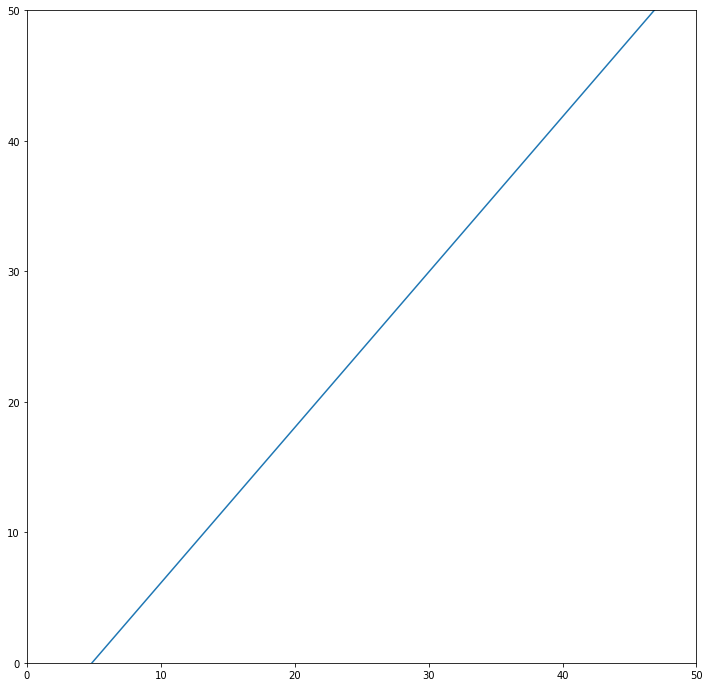

In [154]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn2312)
#plt.contourf(X,Y,Eqn12)
plt.axis([0,50,0,50])

In [155]:
W31 = meu1[0] - meu1[2]
W31

array([ 11.95370514, -15.93828229])

In [157]:
Eqn2313 = 11.95370514*(X1)/15.93828229 - 11.95370514*(meu1[0][0]+meu1[2][0])/(2*15.93828229)+(meu1[0][1]+meu1[2][1])/2

(0.0, 50.0, 0.0, 50.0)

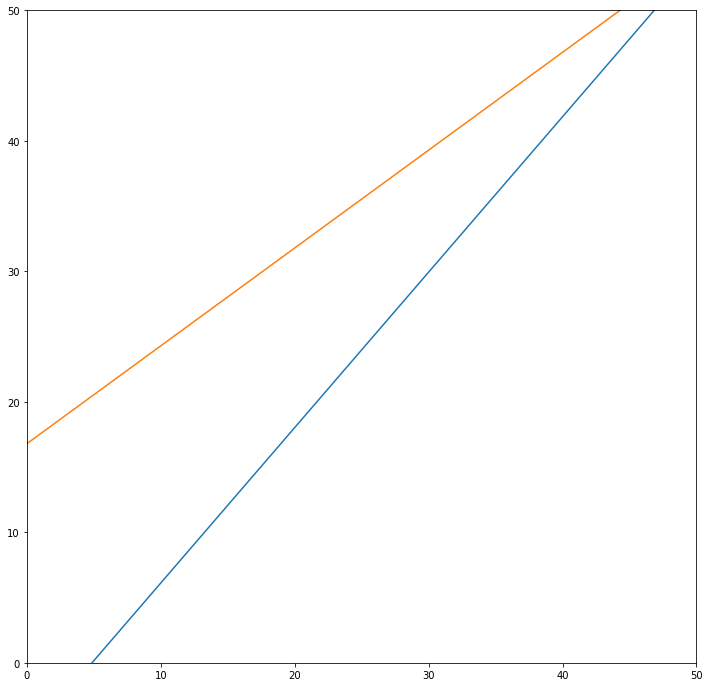

In [159]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn2312)
plt.plot(X1,Eqn2313)
#plt.contourf(X,Y,Eqn12)
plt.axis([0,50,0,50])

In [160]:
W31 = meu1[1] - meu1[2]
W31

array([ 10.59633314, -14.79886286])

In [163]:
Eqn2323 = 10.59633314*(X1)/14.79886286 - 10.59633314*(meu1[1][0]+meu1[2][0])/(2*14.79886286)+(meu1[1][1]+meu1[2][1])/2

(0.0, 50.0, 0.0, 50.0)

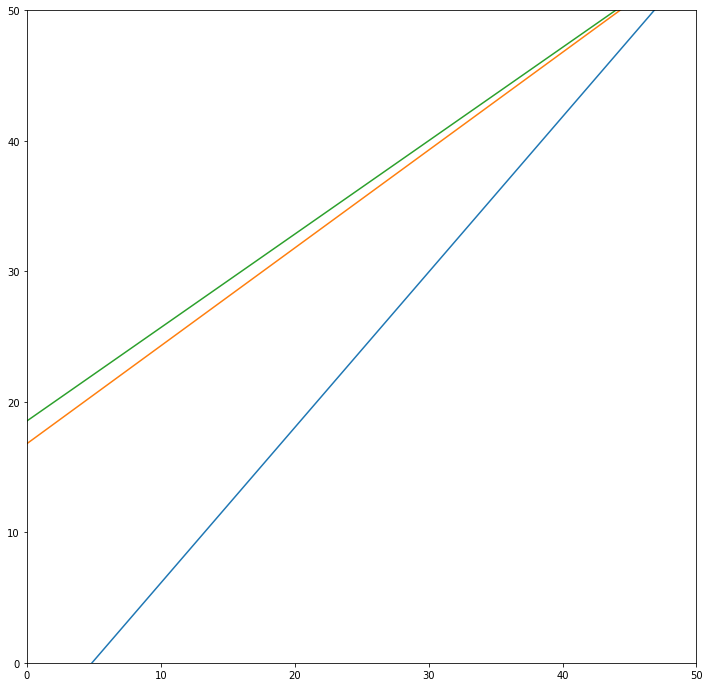

In [164]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn2312)
plt.plot(X1,Eqn2313)
plt.plot(X1,Eqn2323)
#plt.contourf(X,Y,Eqn12)
plt.axis([0,50,0,50])

Case4

In [165]:
conv1

array([[ 55.40949861, -35.65689215],
       [-35.65689215,  77.3833439 ]])

In [166]:
cov = conv1
cov[0][1]=0
cov[1][0]=0
W4 = np.linalg.inv(cov)@(meu[0]-meu[1])
print(conv)
print(W4)

[[23.81339307  1.12367789]
 [ 1.12367789 22.93995337]]
[-0.19048573 -0.13776654]


In [167]:
W4 = np.linalg.inv(cov)@(meu[0]-meu[1])

print(W4)

[-0.19048573 -0.13776654]


In [168]:
Eqn2412 = -0.19048573*(X1)/0.13776654+0.19048573*(meu1[0][0]+meu1[1][0])/(2*0.13776654)+(meu1[0][1]+meu1[1][1])/2

(0.0, 50.0, 0.0, 50.0)

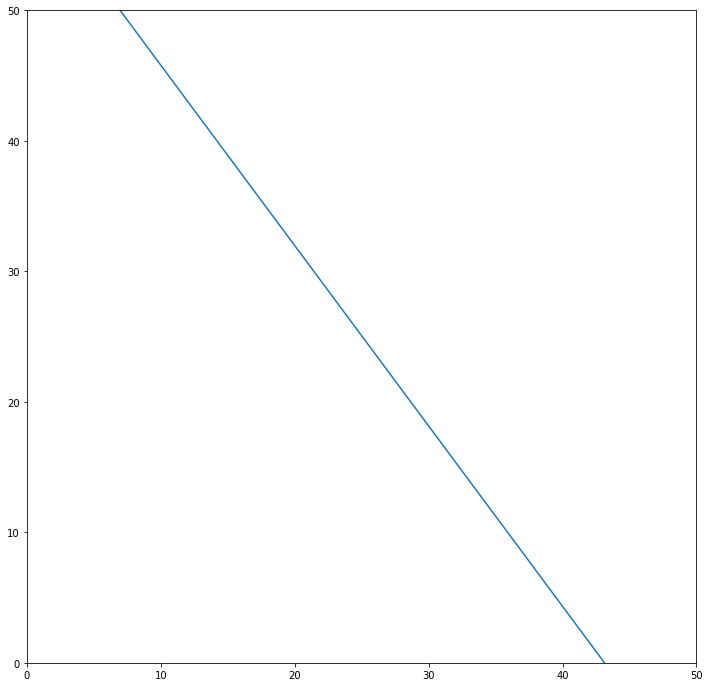

In [169]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn2412)
#plt.contourf(X,Y,Eqn12)
plt.axis([0,50,0,50])

In [170]:
W4 = np.linalg.inv(cov)@(meu[0]-meu[2])

print(W4)

[-0.20099703  0.09906135]


In [171]:
Eqn2413 = 0.20099703*(X1)/0.09906135 - 0.20099703*(meu1[0][0]+meu1[2][0])/(2*0.09906135)+(meu1[0][1]+meu1[2][1])/2

(0.0, 50.0, 0.0, 50.0)

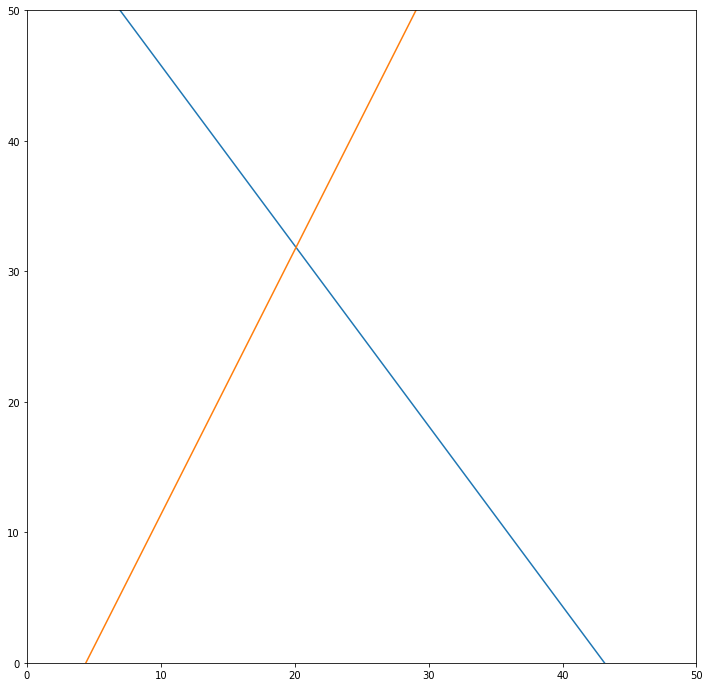

In [172]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn2412)
plt.plot(X1,Eqn2413)
#plt.contourf(X,Y,Eqn12)
plt.axis([0,50,0,50])

In [188]:
W4 = np.linalg.inv(cov)@(meu[1]-meu[2])

print(W4)

[-0.0105113   0.23682789]


In [189]:
Eqn2423 = 0.0105113*(X1)/0.23682789 - 0.0105113*(meu1[1][0]+meu1[2][0])/(2*0.23682789)+(meu1[1][1]+meu1[2][1])/2

(0.0, 50.0, 0.0, 50.0)

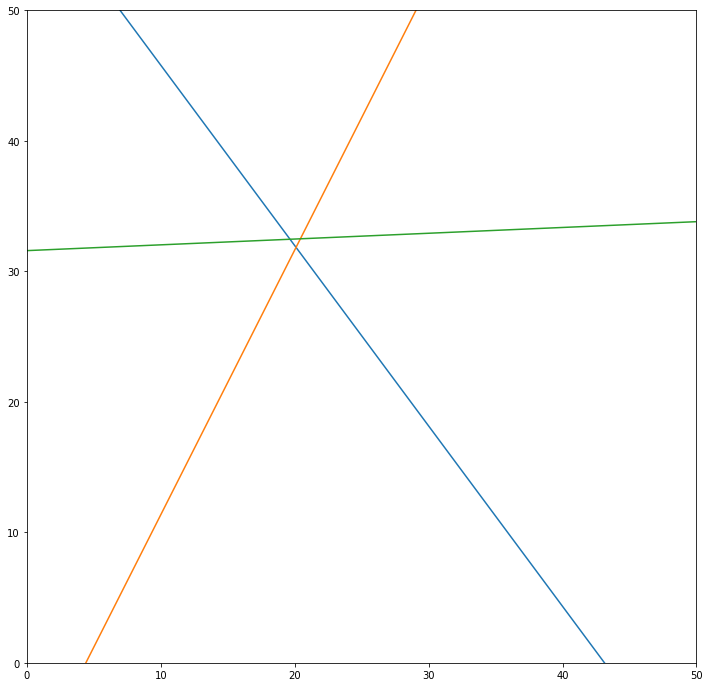

In [190]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn2412)
plt.plot(X1,Eqn2413)
plt.plot(X1,Eqn2423)
#plt.contourf(X,Y,Eqn12)
plt.axis([0,50,0,50])

case 5

In [191]:
cov = Covariance_Matrix1
cov[0][0][1]=0 
cov[0][1][0]=0
cov[1][0][1]=0 
cov[1][1][0]=0
cov[2][0][1]=0 
cov[2][1][0]=0
cov

array([[[51.55986106,  0.        ],
        [ 0.        , 44.28784134]],

       [[ 5.25536251,  0.        ],
        [ 0.        ,  6.8015004 ]],

       [[23.81339307,  0.        ],
        [ 0.        , 22.93995337]]])

In [192]:
w1 = (np.linalg.inv(cov[0])@meu1[0]-np.linalg.inv(cov[1])@meu1[1])
w01 = -0.5*(meu1[0].T@np.linalg.inv(cov[0])@meu1[0]-meu1[1].T@np.linalg.inv(cov[1])@meu1[1])-0.5*np.log(np.abs(np.linalg.det(cov[0])/np.linalg.det(cov[1])))
W1 = -0.5*(np.linalg.inv(cov[0])-np.linalg.inv(cov[1]))
print(w1,w01,W1)

[-4.20210709 -3.14390343] 89.26140153016807 [[ 0.08544345 -0.        ]
 [-0.          0.06222341]]


In [193]:
Eqn2512 =0.08544345*X**2 + 0.06222341*Y**2 - 4.20210709*X - 3.14390343*Y + 89.26140153016807

(0.0, 50.0, 0.0, 50.0)

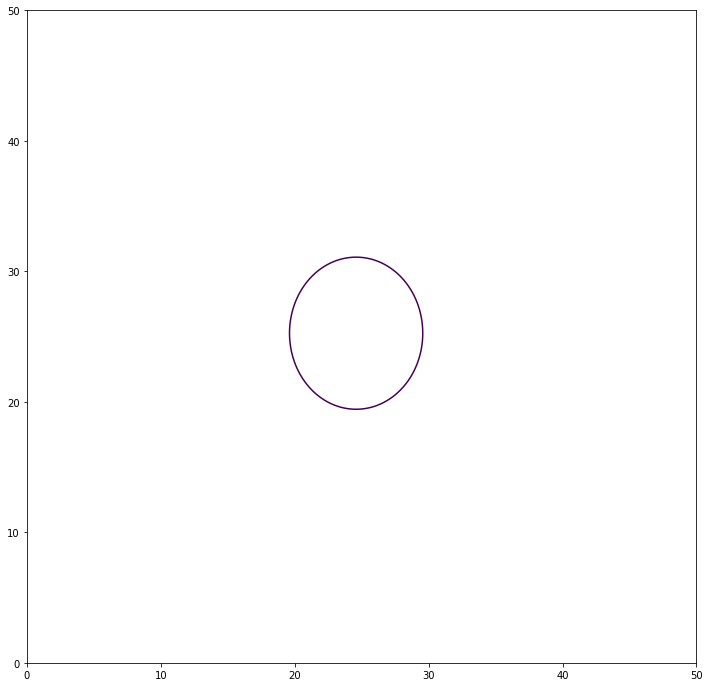

In [194]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X,Y,Eqn2512,[0])
#plt.contourf(X,Y,Eqn12)
plt.axis([0,50,0,50])

In [195]:
w1 = (np.linalg.inv(cov[0])@meu1[0]-np.linalg.inv(cov[2])@meu1[2])
w01 = -0.5*(meu1[0].T@np.linalg.inv(cov[0])@meu1[0]-meu1[2].T@np.linalg.inv(cov[2])@meu1[2])-0.5*np.log(np.abs(np.linalg.det(cov[0])/np.linalg.det(cov[2])))
W1 = -0.5*(np.linalg.inv(cov[0])-np.linalg.inv(cov[2]))
print(w1,w01,W1)

[-0.08787216 -1.19733612] 25.04434184188464 [[ 0.01129912 -0.        ]
 [-0.          0.01050625]]


In [196]:
Eqn2513 =0.01129912*X**2 + 0.01050625*Y**2 - 0.08787216*X - 1.19733612*Y + 25.04434184188464

(0.0, 50.0, 0.0, 50.0)

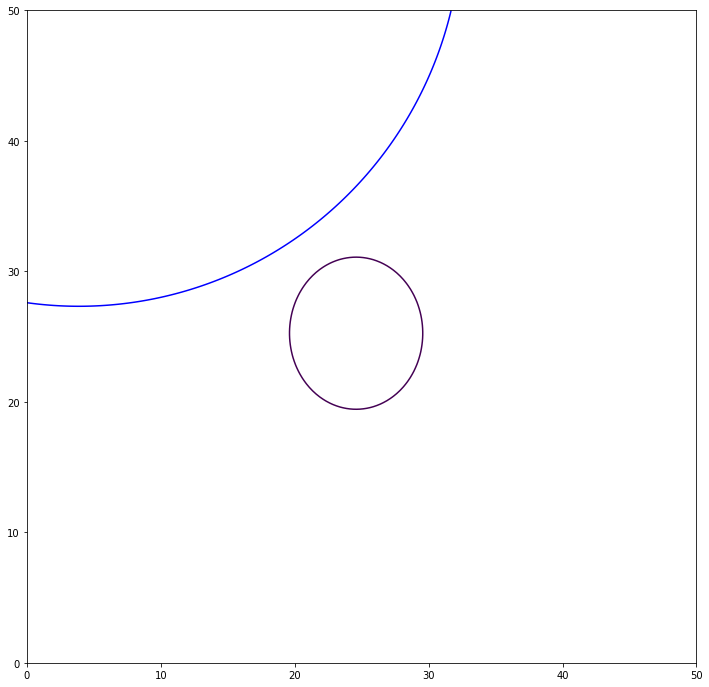

In [197]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X,Y,Eqn2512,[0])
plt.contour(X,Y,Eqn2513,[0],colors=["b"])
#plt.contourf(X,Y,Eqn12)
plt.axis([0,50,0,50])

In [198]:
w1 = (np.linalg.inv(cov[1])@meu1[1]-np.linalg.inv(cov[2])@meu1[2])
w01 = -0.5*(meu1[1].T@np.linalg.inv(cov[1])@meu1[1]-meu1[2].T@np.linalg.inv(cov[2])@meu1[2])-0.5*np.log(np.abs(np.linalg.det(cov[1])/np.linalg.det(cov[2])))
W1 = -0.5*(np.linalg.inv(cov[1])-np.linalg.inv(cov[2]))
print(w1,w01,W1)

[4.11423494 1.94656731] -64.21705968828343 [[-0.07414433 -0.        ]
 [-0.         -0.05171716]]


In [199]:
Eqn2523 = -0.07414433*X**2 - 0.05171716*Y**2 + 4.11423494*X + 1.94656731*Y - 64.21705968828343

(0.0, 50.0, 0.0, 50.0)

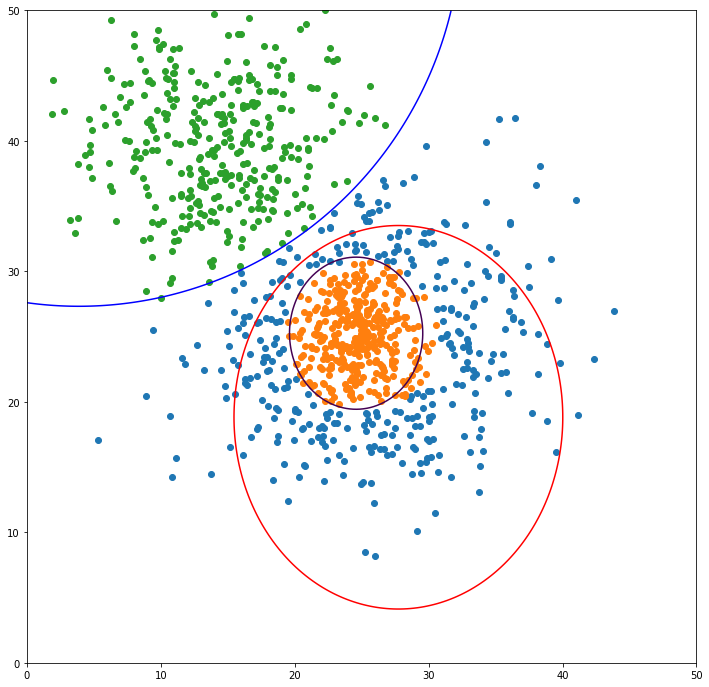

In [201]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X,Y,Eqn2512,[0])
plt.contour(X,Y,Eqn2513,[0],colors=["b"])
plt.contour(X,Y,Eqn2523,[0],colors=["r"])
plt.scatter(Data21[:,0],Data21[:,1])
plt.scatter(Data22[:,0],Data22[:,1])
plt.scatter(Data23[:,0],Data23[:,1])
#plt.contourf(X,Y,Eqn12)
plt.axis([0,50,0,50])

Real Data


In [203]:
from numpy import loadtxt
RLData = loadtxt("trian (1).txt", delimiter=",", unpack=False)

In [206]:
Data3 = separate_by_class(RLData)

In [207]:
Data31=np.asarray(Data3[1.0])
Data32=np.asarray(Data3[2.0])
Data33=np.asarray(Data3[3.0])

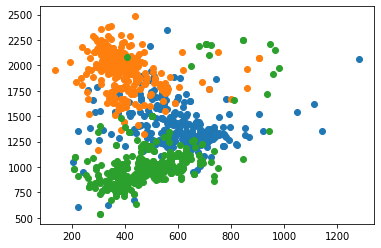

In [232]:
plt.scatter(Data31[:,0],Data31[:,1])
plt.scatter(Data32[:,0],Data32[:,1])
plt.scatter(Data33[:,0],Data33[:,1])

In [209]:
meu2 = []
for i in Data3:
  M = []
  for j in range(len(Data3[i][0])-1):
    Data = np.asarray(Data3[i])
    M.append(np.sum(Data[:][:,j])/len(Data[:][:,j]))
  meu2.append(M)

In [210]:
Covariance_Matrix2 = []
for i in Data3:
  Data = np.asarray(Data3[i])
  conv = np.zeros([2,2])
  for k in range(0, 2):
    for j in range(0, 2):
      a = Data[:][:,k]
      b = Data[:][:,j]
      a_mean = np.mean(a)
      b_mean = np.mean(b)
      sum = 0
      for l in range(0, len(a)):
          sum += ((a[l] - a_mean) * (b[l] - b_mean))
      #print(sum/len(a)-1)
      conv[k][j] = sum/(len(a)-1)
  Covariance_Matrix2.append(conv)

In [211]:
meu2 = np.asarray(meu2)
Covariance_Matrix2 = np.asarray(Covariance_Matrix2)

In [212]:
meu2

array([[ 573.00534286, 1430.35805714],
       [ 407.12908571, 1912.326     ],
       [ 485.42428571, 1043.17382857]])

In [213]:
Covariance_Matrix2

array([[[17958.37112237, -3360.13007068],
        [-3360.13007068, 43399.34524206]],

       [[ 9706.60523813, -7985.91024264],
        [-7985.91024264, 50112.5452533 ]],

       [[18659.92213516, 22286.27496492],
        [22286.27496492, 78618.47127871]]])

Case1

In [214]:
conv2 = np.zeros([2,2])
for k in range(0, 2):
  for j in range(0, 2):
    a = RLData[:][:,k]
    b = RLData[:][:,j]
    a_mean = np.mean(a)
    b_mean = np.mean(b)
    sum = 0
    for l in range(0, len(a)):
        sum += ((a[l] - a_mean) * (b[l] - b_mean))
      #print(sum/len(a)-1)
    conv2[k][j] = sum/(len(a)-1)
print(conv2)

[[ 20007.18084967  -9048.67856179]
 [ -9048.67856179 183791.25085505]]


In [215]:
W = np.linalg.inv(conv2)@(meu2[0]-meu2[1])
X = np.linspace(0,1500 , num=200)
Y = np.linspace(500, 2500, num=200)
X, Y = np.meshgrid(X, Y)
print(W)

[ 0.00726662 -0.00226461]


In [222]:
X1 = np.linspace(0,1500 , num=200)
Eqn3112 =0.00726662*(X1)/0.00226461 - 0.00726662*(meu2[0][0]+meu2[1][0])/(2*0.00226461)+(meu2[0][1]+meu2[1][1])/2

(0.0, 1500.0, 500.0, 2500.0)

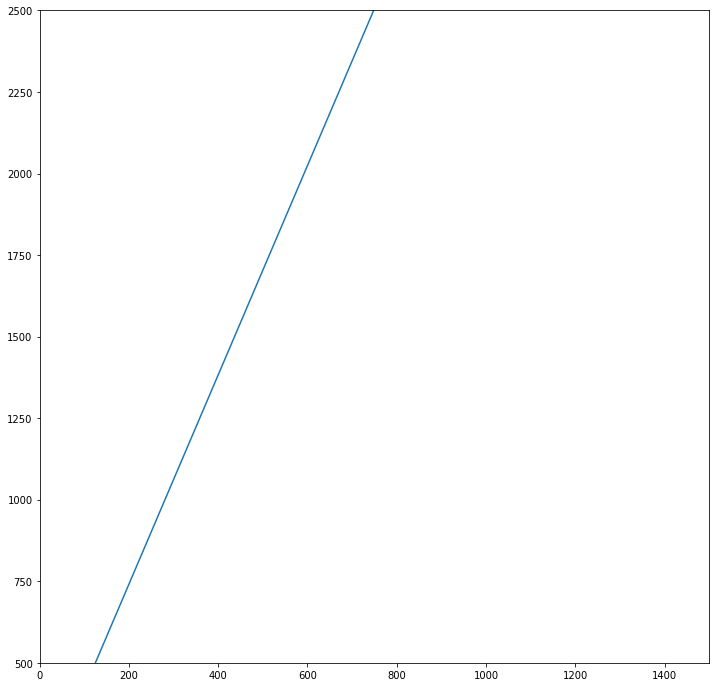

In [219]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn3112)
plt.axis([0,1500,500,2500])

In [220]:
W = np.linalg.inv(conv2)@(meu2[0]-meu2[2])
print(W)

[0.00545165 0.00237506]


In [223]:
Eqn3113 =-0.00545165*(X1)/0.00237506 + 0.00545165*(meu2[0][0]+meu2[2][0])/(2*0.00237506)+(meu2[0][1]+meu2[2][1])/2

(0.0, 1500.0, 500.0, 2500.0)

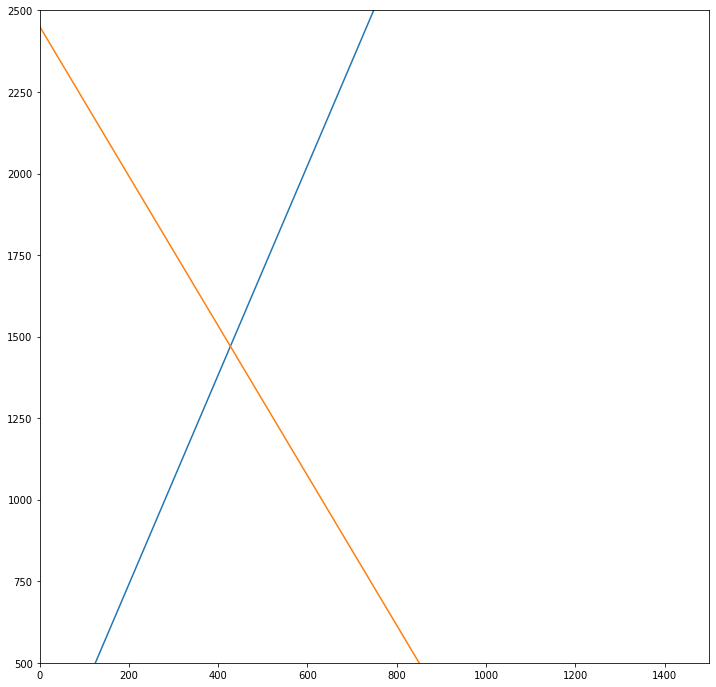

In [224]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn3112)
plt.plot(X1,Eqn3113)
plt.axis([0,1500,500,2500])

In [225]:
W = np.linalg.inv(conv2)@(meu2[1]-meu2[2])
print(W)

[-0.00181497  0.00463966]


In [226]:
Eqn3123 = 0.00181497*(X1)/0.00463966 - 0.00181497*(meu2[1][0]+meu2[2][0])/(2*0.00463966)+(meu2[1][1]+meu2[2][1])/2

(0.0, 1500.0, 500.0, 2500.0)

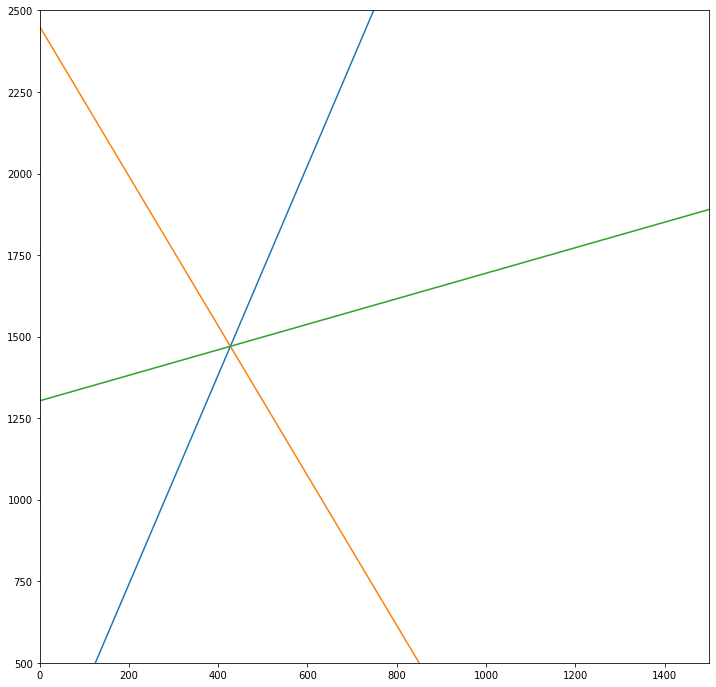

In [227]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn3112)
plt.plot(X1,Eqn3113)
plt.plot(X1,Eqn3123)
plt.axis([0,1500,500,2500])

In [228]:
idx = np.argwhere(np.diff(np.sign(Eqn3112 - Eqn3113))).flatten()
idx

array([56])

(0.0, 1500.0, 500.0, 2500.0)

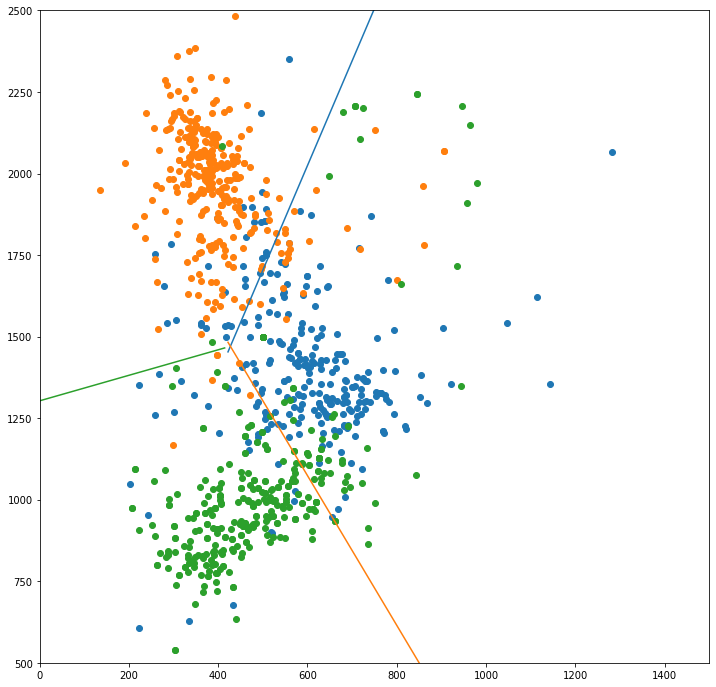

In [235]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1[56:],Eqn3112[56:])
plt.plot(X1[56:],Eqn3113[56:])
plt.plot(X1[:56],Eqn3123[:56])
plt.scatter(Data31[:,0],Data31[:,1])
plt.scatter(Data32[:,0],Data32[:,1])
plt.scatter(Data33[:,0],Data33[:,1])
plt.axis([0,1500,500,2500])

case2

In [236]:
Covarience_Matrix2 = []
for i in Data3:
  Data = np.asarray(Data3[i])
  Covarience_Matrix2.append(np.cov(Data[:][:,0],Data[:][:,1]))

In [237]:
Covariance_Matrix2

array([[[17958.37112237, -3360.13007068],
        [-3360.13007068, 43399.34524206]],

       [[ 9706.60523813, -7985.91024264],
        [-7985.91024264, 50112.5452533 ]],

       [[18659.92213516, 22286.27496492],
        [22286.27496492, 78618.47127871]]])

In [238]:
Covarience_Matrix2

[array([[17958.37112237, -3360.13007068],
        [-3360.13007068, 43399.34524206]]),
 array([[ 9706.60523813, -7985.91024264],
        [-7985.91024264, 50112.5452533 ]]),
 array([[18659.92213516, 22286.27496492],
        [22286.27496492, 78618.47127871]])]

In [239]:
w1 = (np.linalg.inv(Covariance_Matrix2[0])@meu2[0]-np.linalg.inv(Covariance_Matrix2[1])@meu2[1])
w01 = -0.5*(meu2[0].T@np.linalg.inv(Covariance_Matrix2[0])@meu2[0]-meu2[1].T@np.linalg.inv(Covariance_Matrix2[1])@meu2[1])-0.5*np.log(np.abs(np.linalg.det(Covariance_Matrix2[0])/np.linalg.det(Covariance_Matrix2[1])))
W1 = -0.5*(np.linalg.inv(Covariance_Matrix2[0])-np.linalg.inv(Covariance_Matrix2[1]))
print(w1,w01,W1)

[-0.04577204 -0.01566227] 29.453540575222025 [[ 3.10325981e-05  7.26014817e-06]
 [ 7.26014817e-06 -2.07175396e-07]]


In [242]:
Eqn3212 = 3.10325981e-05*X**2  - 2.07175396e-07*Y**2 + 2*7.26014817e-06*X*Y - 0.04577204*X - 0.01566227*Y + 29.453540575222025

(0.0, 1500.0, 500.0, 2500.0)

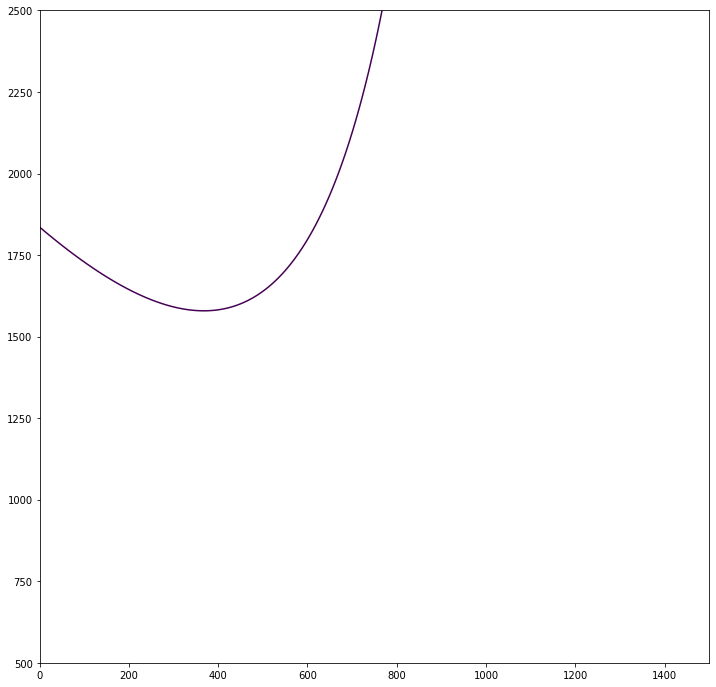

In [243]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X,Y,Eqn3212,[0])
#plt.contourf(X,Y,Eqn12)
plt.axis([0,1500,500,2500])

In [245]:
w1 = (np.linalg.inv(Covariance_Matrix2[0])@meu2[0]-np.linalg.inv(Covariance_Matrix2[2])@meu2[2])
w01 = -0.5*(meu2[0].T@np.linalg.inv(Covariance_Matrix2[0])@meu2[0]-meu2[2].T@np.linalg.inv(Covariance_Matrix2[2])@meu2[2])-0.5*np.log(np.abs(np.linalg.det(Covariance_Matrix2[0])/np.linalg.det(Covariance_Matrix2[2])))
W1 = -0.5*(np.linalg.inv(Covariance_Matrix2[0])-np.linalg.inv(Covariance_Matrix2[2]))
print(w1,w01,W1)

[0.02326295 0.02703763] -28.283082855453845 [[ 1.22594998e-05 -1.36711121e-05]
 [-1.36711121e-05 -2.07508058e-06]]


In [252]:
Eqn3213 = 1.22594998e-05*X**2  - 2.07508058e-06*Y**2 - 2*1.36711121e-05*X*Y + 0.02326295*X + 0.02703763*Y - 28.283082855453845

(0.0, 1500.0, 500.0, 2500.0)

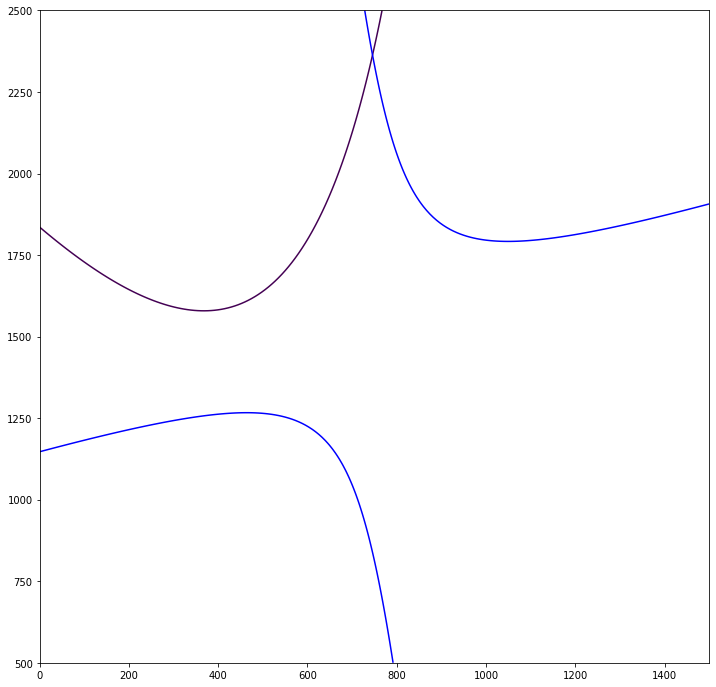

In [248]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X,Y,Eqn3212,[0])
plt.contour(X,Y,Eqn3213,[0],colors=["b"])
#plt.contourf(X,Y,Eqn12)
plt.axis([0,1500,500,2500])

In [249]:
w1 = (np.linalg.inv(Covariance_Matrix2[1])@meu2[1]-np.linalg.inv(Covariance_Matrix2[2])@meu2[2])
w01 = -0.5*(meu2[1].T@np.linalg.inv(Covariance_Matrix2[1])@meu2[1]-meu2[2].T@np.linalg.inv(Covariance_Matrix2[2])@meu2[2])-0.5*np.log(np.abs(np.linalg.det(Covariance_Matrix2[1])/np.linalg.det(Covariance_Matrix2[2])))
W1 = -0.5*(np.linalg.inv(Covariance_Matrix2[1])-np.linalg.inv(Covariance_Matrix2[2]))
print(w1,w01,W1)

[0.069035  0.0426999] -57.73662343067588 [[-1.87730983e-05 -2.09312602e-05]
 [-2.09312602e-05 -1.86790518e-06]]


In [251]:
Eqn3223 = -1.87730983e-05*X**2  - 1.86790518e-06*Y**2 - 2*2.09312602e-05*X*Y + 0.069035*X + 0.0426999*Y - 57.73662343067588

(0.0, 1500.0, 500.0, 2500.0)

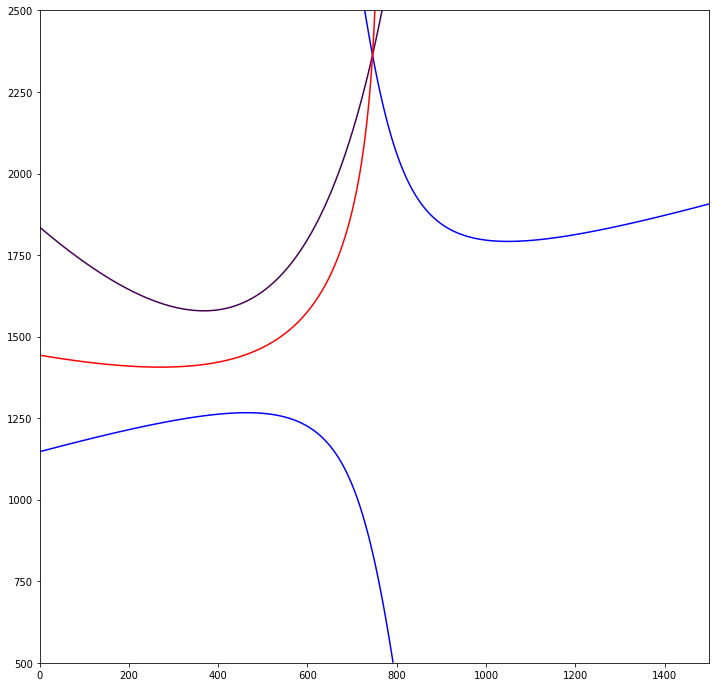

In [253]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
#plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X,Y,Eqn3212,[0])
plt.contour(X,Y,Eqn3213,[0],colors=["b"])
plt.contour(X,Y,Eqn3223,[0],colors=["r"])
#plt.contourf(X,Y,Eqn12)
plt.axis([0,1500,500,2500])